PNG: C:\Users\HP 850 G7\output\fp_64_8x4_springer_final_largerfont.png
PDF: C:\Users\HP 850 G7\output\fp_64_8x4_springer_final_largerfont.pdf


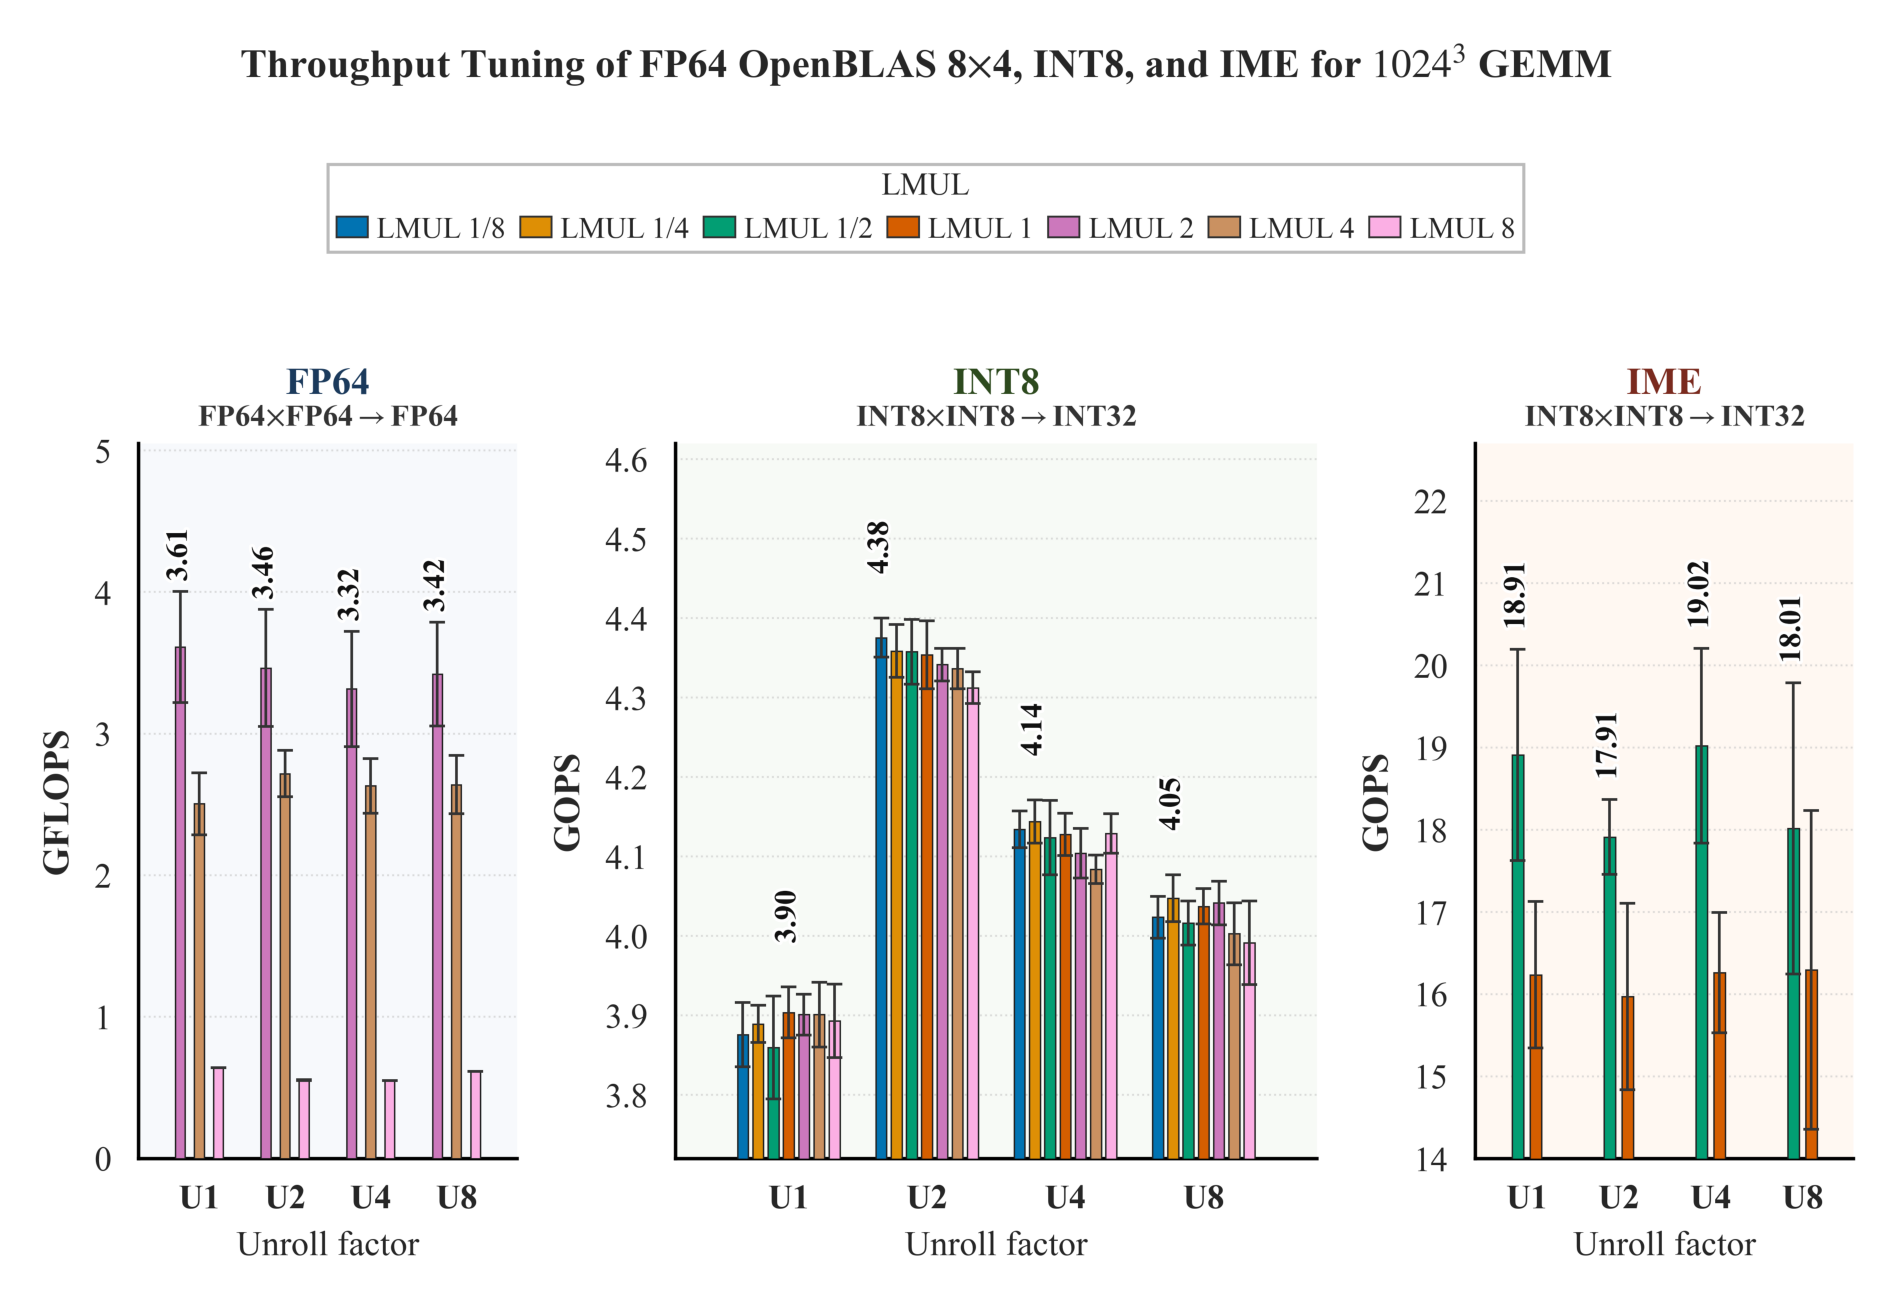

In [35]:
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.patheffects as pe
import seaborn as sns
from matplotlib.patches import Patch
from IPython.display import Image, display

# ─────────────────────────────────────────────────────────────
# Springer / publication style
# ─────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", context="paper")

matplotlib.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",

    "axes.linewidth": 0.90,
    "axes.edgecolor": "black",
    "axes.spines.top": False,
    "axes.spines.right": False,

    "xtick.major.width": 0.80,
    "ytick.major.width": 0.80,
    "xtick.major.size": 3.6,
    "ytick.major.size": 3.6,
    "xtick.direction": "out",
    "ytick.direction": "out",
})

# ─────────────────────────────────────────────────────────────
# Output
# ─────────────────────────────────────────────────────────────
OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

SAVE_PATH_PNG = os.path.join(OUTPUT_DIR, "fp_64_8x4_springer_final_largerfont.png")
SAVE_PATH_PDF = os.path.join(OUTPUT_DIR, "fp_64_8x4_springer_final_largerfont.pdf")

# ─────────────────────────────────────────────────────────────
# Data
# ─────────────────────────────────────────────────────────────
DATA = [
    # FP64
    ("FP64", "2",   1, 3.613117, 0.392615),
    ("FP64", "2",   2, 3.464250, 0.412135),
    ("FP64", "2",   4, 3.316667, 0.407032),
    ("FP64", "2",   8, 3.421700, 0.367016),
    ("FP64", "4",   1, 2.504333, 0.219997),
    ("FP64", "4",   2, 2.717317, 0.163361),
    ("FP64", "4",   4, 2.630733, 0.194312),
    ("FP64", "4",   8, 2.640033, 0.205592),
    ("FP64", "8",   1, 0.640517, 0.000474),
    ("FP64", "8",   2, 0.554383, 0.003143),
    ("FP64", "8",   4, 0.550567, 0.000259),
    ("FP64", "8",   8, 0.615300, 0.000792),

    # INT8
    ("INT8", "mf8", 1, 3.875800, 0.040295),
    ("INT8", "mf8", 2, 4.375483, 0.024772),
    ("INT8", "mf8", 4, 4.134017, 0.023203),
    ("INT8", "mf8", 8, 4.023583, 0.026163),
    ("INT8", "mf4", 1, 3.889300, 0.023601),
    ("INT8", "mf4", 2, 4.358783, 0.033337),
    ("INT8", "mf4", 4, 4.144000, 0.027036),
    ("INT8", "mf4", 8, 4.047717, 0.029463),
    ("INT8", "mf2", 1, 3.859500, 0.064757),
    ("INT8", "mf2", 2, 4.357717, 0.040958),
    ("INT8", "mf2", 4, 4.123767, 0.047008),
    ("INT8", "mf2", 8, 4.016267, 0.027970),
    ("INT8", "1",   1, 3.903833, 0.031932),
    ("INT8", "1",   2, 4.353900, 0.042700),
    ("INT8", "1",   4, 4.127933, 0.026498),
    ("INT8", "1",   8, 4.037267, 0.022109),
    ("INT8", "2",   1, 3.901133, 0.025815),
    ("INT8", "2",   2, 4.341533, 0.020722),
    ("INT8", "2",   4, 4.104183, 0.031354),
    ("INT8", "2",   8, 4.041517, 0.027563),
    ("INT8", "4",   1, 3.901167, 0.040827),
    ("INT8", "4",   2, 4.336433, 0.025418),
    ("INT8", "4",   4, 4.084000, 0.018035),
    ("INT8", "4",   8, 4.002850, 0.039010),
    ("INT8", "8",   1, 3.893183, 0.046150),
    ("INT8", "8",   2, 4.312500, 0.020111),
    ("INT8", "8",   4, 4.128867, 0.024786),
    ("INT8", "8",   8, 3.991517, 0.052737),

    # IME
    ("IME",  "mf2", 1, 18.909100, 1.284403),
    ("IME",  "mf2", 2, 17.911000, 0.457397),
    ("IME",  "mf2", 4, 19.019133, 1.185327),
    ("IME",  "mf2", 8, 18.012617, 1.771497),
    ("IME",  "1",   1, 16.234000, 0.892657),
    ("IME",  "1",   2, 15.969633, 1.135141),
    ("IME",  "1",   4, 16.261900, 0.732974),
    ("IME",  "1",   8, 16.294133, 1.938344),
]

df = pd.DataFrame(DATA, columns=["Family", "LMUL", "Unroll", "Mean", "Std"])

# ─────────────────────────────────────────────────────────────
# Constants
# ─────────────────────────────────────────────────────────────
FAMILIES = ["FP64", "INT8", "IME"]
UNROLLS = [1, 2, 4, 8]
LMUL_ORDER = ["mf8", "mf4", "mf2", "1", "2", "4", "8"]

LMUL_LABEL = {
    "mf8": "LMUL 1/8",
    "mf4": "LMUL 1/4",
    "mf2": "LMUL 1/2",
    "1":   "LMUL 1",
    "2":   "LMUL 2",
    "4":   "LMUL 4",
    "8":   "LMUL 8",
}

palette = sns.color_palette("colorblind", 7)

LMUL_COLORS = {
    "mf8": palette[0],
    "mf4": palette[1],
    "mf2": palette[2],
    "1":   palette[3],
    "2":   palette[4],
    "4":   palette[5],
    "8":   palette[6],
}

FAMILY_FACE = {
    "FP64": "#F7F9FC",
    "INT8": "#F7FAF6",
    "IME":  "#FFF8F2",
}

FAMILY_ACCENT = {
    "FP64": "#1B3A5C",
    "INT8": "#2D4A1E",
    "IME":  "#7A2A1E",
}

FAMILY_SUBTITLE = {
    "FP64": r"FP64$\times$FP64$\rightarrow$FP64",
    "INT8": r"INT8$\times$INT8$\rightarrow$INT32",
    "IME":  r"INT8$\times$INT8$\rightarrow$INT32",
}

FAMILY_YLABEL = {
    "FP64": "GFLOPS",
    "INT8": "GOPS",
    "IME":  "GOPS",
}

UNROLL_LABEL = {
    1: "U1",
    2: "U2",
    4: "U4",
    8: "U8",
}

Y_LIMITS = {
    "FP64": (0.0, 5.05),
    "INT8": (3.72, 4.62),
    "IME":  (14.0, 22.7),
}

BAR_WIDTH = {
    "FP64": 0.115,
    "INT8": 0.078,
    "IME":  0.125,
}

GROUP_WIDTH = {
    "FP64": 0.56,
    "INT8": 0.74,
    "IME":  0.32,
}

LABEL_FONT = {
    "FP64": 8.0,
    "INT8": 8.0,
    "IME":  8.0,
}

CAPSIZE = 2.0

LABEL_Y_OFFSET = {
    "FP64": 0.070,
    "INT8": 0.055,
    "IME":  0.24,
}

# ─────────────────────────────────────────────────────────────
# Helpers
# ─────────────────────────────────────────────────────────────
def present_lmuls_for_family(fam):
    present = set(df.loc[df["Family"] == fam, "LMUL"])
    return [l for l in LMUL_ORDER if l in present]

def add_label(ax, x, y, text, fontsize):
    label = ax.text(
        x,
        y,
        text,
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=fontsize,
        fontweight="bold",
        color="#111111",
        zorder=9,
        clip_on=False,
    )
    label.set_path_effects([
        pe.Stroke(linewidth=1.6, foreground="white"),
        pe.Normal(),
    ])
    return label

# ─────────────────────────────────────────────────────────────
# Figure
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    1, 3,
    figsize=(6.8, 4.85),
    dpi=300,
    gridspec_kw={
        "width_ratios": [1.15, 1.95, 1.15],
        "wspace": 0.34,
    }
)

fig.suptitle(
    r"Throughput Tuning of FP64 OpenBLAS 8$\times$4, INT8, and IME for $1024^3$ GEMM",
    fontsize=10.5,
    fontweight="bold",
    y=0.970,
)

for ax, fam in zip(axes, FAMILIES):
    sub = df[df["Family"] == fam].copy()
    lmuls = present_lmuls_for_family(fam)

    x = np.arange(len(UNROLLS))
    total_width = GROUP_WIDTH[fam]
    bar_width = BAR_WIDTH[fam]

    offsets = np.linspace(
        -total_width / 2 + bar_width / 2,
         total_width / 2 - bar_width / 2,
        len(lmuls)
    )

    ax.set_facecolor(FAMILY_FACE[fam])
    bar_info = {}

    for offset, lmul in zip(offsets, lmuls):
        s = sub[sub["LMUL"] == lmul].set_index("Unroll").reindex(UNROLLS)
        vals = s["Mean"].values
        errs = s["Std"].values
        xpos = x + offset

        ax.bar(
            xpos,
            vals,
            width=bar_width,
            color=LMUL_COLORS[lmul],
            edgecolor="#222222",
            linewidth=0.38,
            yerr=errs,
            capsize=CAPSIZE,
            error_kw=dict(
                elinewidth=0.70,
                ecolor="#333333",
                capthick=0.70,
            ),
            zorder=3,
        )

        for i, u in enumerate(UNROLLS):
            bar_info[(lmul, u)] = {
                "x": xpos[i],
                "mean": vals[i],
                "std": errs[i],
            }

    # Label only the best value per unroll group
    for u in UNROLLS:
        records_u = [bar_info[(lmul, u)] for lmul in lmuls]
        best_rec = max(records_u, key=lambda r: r["mean"])

        add_label(
            ax,
            best_rec["x"],
            best_rec["mean"] + best_rec["std"] + LABEL_Y_OFFSET[fam],
            f"{best_rec['mean']:.2f}",
            LABEL_FONT[fam],
        )

    ax.set_title(
        fam,
        fontsize=10.0,
        fontweight="bold",
        color=FAMILY_ACCENT[fam],
        pad=13,
    )

    ax.text(
        0.5,
        1.016,
        FAMILY_SUBTITLE[fam],
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=8.0,
        fontweight="bold",
        color="#333333",
    )

    ax.set_xticks(x)
    ax.set_xticklabels(
        [UNROLL_LABEL[u] for u in UNROLLS],
        fontsize=9.0,
        fontweight="bold",
    )

    ax.set_xlabel("Unroll factor", fontsize=9.2, labelpad=4)
    ax.set_ylabel(
        FAMILY_YLABEL[fam],
        fontsize=9.6,
        fontweight="bold",
        labelpad=5,
    )

    ax.set_ylim(*Y_LIMITS[fam])
    ax.tick_params(axis="y", labelsize=9.0)

    ax.grid(
        axis="y",
        linestyle=":",
        linewidth=0.50,
        color="#C7C7C7",
        alpha=0.60,
        zorder=0,
    )
    ax.grid(False, axis="x")

    ax.set_axisbelow(True)
    ax.margins(x=0.12)

# ─────────────────────────────────────────────────────────────
# Legend
# ─────────────────────────────────────────────────────────────
present_lmuls = [l for l in LMUL_ORDER if l in set(df["LMUL"])]

legend_handles = [
    Patch(
        facecolor=LMUL_COLORS[l],
        edgecolor="#333333",
        linewidth=0.50,
        label=LMUL_LABEL[l],
    )
    for l in present_lmuls
]

fig.legend(
    handles=legend_handles,
    ncol=7,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.890),
    frameon=True,
    framealpha=1.0,
    fancybox=False,
    edgecolor="#BBBBBB",
    fontsize=7.8,
    title="LMUL",
    title_fontsize=8.2,
    borderpad=0.28,
    handlelength=1.05,
    handletextpad=0.30,
    columnspacing=0.48,
)

plt.subplots_adjust(
    left=0.080,
    right=0.995,
    bottom=0.135,
    top=0.670,
    wspace=0.34,
)

# ─────────────────────────────────────────────────────────────
# Save
# ─────────────────────────────────────────────────────────────
plt.savefig(SAVE_PATH_PNG, dpi=600, facecolor="white", bbox_inches="tight")
plt.savefig(SAVE_PATH_PDF, facecolor="white", bbox_inches="tight")

print(f"PNG: {os.path.abspath(SAVE_PATH_PNG)}")
print(f"PDF: {os.path.abspath(SAVE_PATH_PDF)}")

plt.close()

# ─────────────────────────────────────────────────────────────
# Notebook preview
# ─────────────────────────────────────────────────────────────
fig_preview, ax_preview = plt.subplots(figsize=(14, 8.5), dpi=150)
img = mpimg.imread(SAVE_PATH_PNG)
ax_preview.imshow(img)
ax_preview.axis("off")
plt.tight_layout(pad=0)
plt.show()

### Throughput Tuning of FP64 OpenBLAS 8$\times$4, INT8, and IME for $1024^3$ GEMM

PNG: C:\Users\HP 850 G7\output\ime_acceleration_scalar_fallback_8x4_1024.png
PDF: C:\Users\HP 850 G7\output\ime_acceleration_scalar_fallback_8x4_1024.pdf


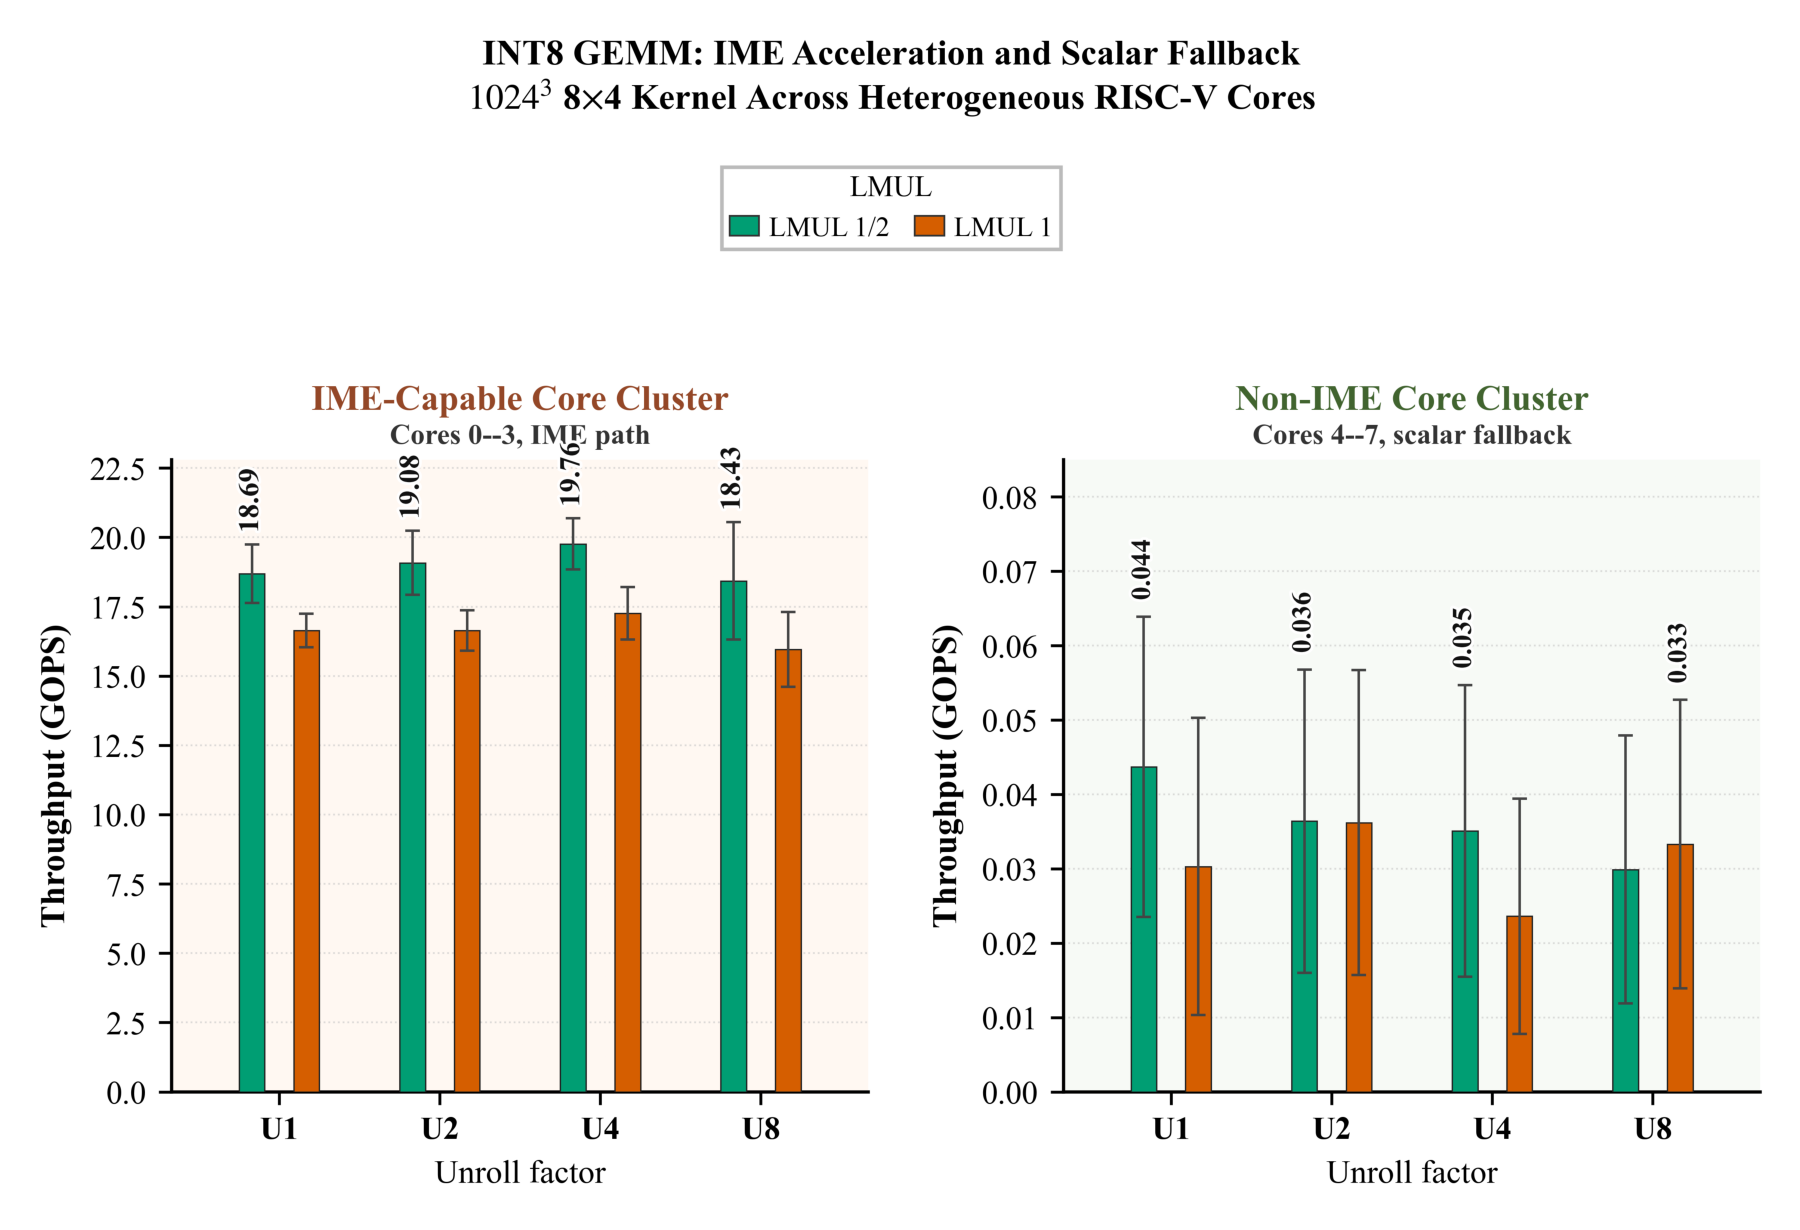

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.patheffects as pe
from matplotlib.patches import Patch

plt.close("all")

matplotlib.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "axes.linewidth": 0.90,
    "xtick.major.width": 0.80,
    "ytick.major.width": 0.80,
    "xtick.minor.width": 0.60,
    "ytick.minor.width": 0.60,
    "xtick.major.size": 3.6,
    "ytick.major.size": 3.6,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
})

OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

SAVE_PATH_PNG = os.path.join(
    OUTPUT_DIR,
    "ime_acceleration_scalar_fallback_8x4_1024.png"
)
SAVE_PATH_PDF = os.path.join(
    OUTPUT_DIR,
    "ime_acceleration_scalar_fallback_8x4_1024.pdf"
)

FIG_W, FIG_H = 6.8, 4.85
BAR_WIDTH = 0.16
GROUP_WIDTH = 0.34
CAPSIZE = 2.0

DATA = [
    ("IME-Capable Core Cluster", "1", 1, 16.6407, 0.6052),
    ("IME-Capable Core Cluster", "1", 2, 16.6404, 0.7303),
    ("IME-Capable Core Cluster", "1", 4, 17.2594, 0.9416),
    ("IME-Capable Core Cluster", "1", 8, 15.9583, 1.3444),

    ("IME-Capable Core Cluster", "mf2", 1, 18.6883, 1.0597),
    ("IME-Capable Core Cluster", "mf2", 2, 19.0822, 1.1558),
    ("IME-Capable Core Cluster", "mf2", 4, 19.7634, 0.9200),
    ("IME-Capable Core Cluster", "mf2", 8, 18.4307, 2.1154),

    ("Non-IME Core Cluster", "1", 1, 0.0303, 0.0200),
    ("Non-IME Core Cluster", "1", 2, 0.0362, 0.0205),
    ("Non-IME Core Cluster", "1", 4, 0.0236, 0.0158),
    ("Non-IME Core Cluster", "1", 8, 0.0333, 0.0194),

    ("Non-IME Core Cluster", "mf2", 1, 0.0437, 0.0202),
    ("Non-IME Core Cluster", "mf2", 2, 0.0364, 0.0204),
    ("Non-IME Core Cluster", "mf2", 4, 0.0351, 0.0196),
    ("Non-IME Core Cluster", "mf2", 8, 0.0299, 0.0180),
]

df = pd.DataFrame(DATA, columns=["Family", "LMUL", "Unroll", "Mean", "Std"])

FAMILIES = [
    "IME-Capable Core Cluster",
    "Non-IME Core Cluster",
]

UNROLLS = [1, 2, 4, 8]
LMUL_ORDER = ["mf2", "1"]

LMUL_LABEL = {
    "mf2": "LMUL 1/2",
    "1": "LMUL 1",
}

LMUL_COLORS = {
    "mf2": "#009E73",
    "1": "#D55E00",
}

FAMILY_FACE = {
    "IME-Capable Core Cluster": "#FFF8F2",
    "Non-IME Core Cluster": "#F7FAF6",
}

FAMILY_ACCENT = {
    "IME-Capable Core Cluster": "#944727",
    "Non-IME Core Cluster": "#41642F",
}

FAMILY_SUBTITLE = {
    "IME-Capable Core Cluster": "Cores 0--3, IME path",
    "Non-IME Core Cluster": "Cores 4--7, scalar fallback",
}

UNROLL_LABEL = {
    1: "U1",
    2: "U2",
    4: "U4",
    8: "U8",
}

Y_LIMITS = {
    "IME-Capable Core Cluster": (0.0, 22.8),
    "Non-IME Core Cluster": (0.0, 0.085),
}

Y_TICKS = {
    "IME-Capable Core Cluster": np.arange(0, 22.6, 2.5),
    "Non-IME Core Cluster": np.arange(0, 0.081, 0.01),
}

LABEL_FONT = {
    "IME-Capable Core Cluster": 8.0,
    "Non-IME Core Cluster": 7.6,
}

LABEL_Y_OFFSET = {
    "IME-Capable Core Cluster": 0.42,
    "Non-IME Core Cluster": 0.0022,
}

VALUE_FORMAT = {
    "IME-Capable Core Cluster": "{:.2f}",
    "Non-IME Core Cluster": "{:.3f}",
}


def add_label(ax, x, y, text, fontsize):
    label = ax.text(
        x,
        y,
        text,
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=fontsize,
        fontweight="bold",
        color="#111111",
        zorder=8,
        clip_on=False,
    )
    label.set_path_effects([
        pe.Stroke(linewidth=1.60, foreground="white"),
        pe.Normal(),
    ])
    return label


fig, axes = plt.subplots(
    1, 2,
    figsize=(FIG_W, FIG_H),
    dpi=300,
    constrained_layout=False,
    gridspec_kw={
        "wspace": 0.28,
        "width_ratios": [1, 1],
    },
)

fig.patch.set_facecolor("white")

fig.suptitle(
    r"INT8 GEMM: IME Acceleration and Scalar Fallback"
    "\n"
    r"$1024^3$ 8$\times$4 Kernel Across Heterogeneous RISC-V Cores",
    fontsize=10.0,
    fontweight="bold",
    y=0.975,
)

for ax, fam in zip(axes, FAMILIES):
    sub = df[df["Family"] == fam].copy()
    lmuls = [l for l in LMUL_ORDER if l in set(sub["LMUL"])]

    x = np.arange(len(UNROLLS))
    offsets = np.linspace(-GROUP_WIDTH / 2, GROUP_WIDTH / 2, len(lmuls))

    ax.set_facecolor(FAMILY_FACE[fam])
    bar_info = {}

    for offset, lmul in zip(offsets, lmuls):
        s = sub[sub["LMUL"] == lmul].set_index("Unroll").reindex(UNROLLS)
        vals = s["Mean"].values
        errs = s["Std"].values
        xpos = x + offset

        ax.bar(
            xpos,
            vals,
            width=BAR_WIDTH,
            color=LMUL_COLORS[lmul],
            edgecolor="#222222",
            linewidth=0.38,
            yerr=errs,
            capsize=CAPSIZE,
            error_kw=dict(
                elinewidth=0.70,
                ecolor="#444444",
                capthick=0.70,
            ),
            zorder=3,
        )

        for i, u in enumerate(UNROLLS):
            bar_info[(lmul, u)] = {
                "x": xpos[i],
                "mean": vals[i],
                "std": errs[i],
            }

    for u in UNROLLS:
        records_u = [bar_info[(lmul, u)] for lmul in lmuls]
        best_rec = max(records_u, key=lambda r: r["mean"])

        add_label(
            ax=ax,
            x=best_rec["x"],
            y=best_rec["mean"] + best_rec["std"] + LABEL_Y_OFFSET[fam],
            text=VALUE_FORMAT[fam].format(best_rec["mean"]),
            fontsize=LABEL_FONT[fam],
        )

    ax.set_title(
        fam,
        fontsize=10.0,
        fontweight="bold",
        color=FAMILY_ACCENT[fam],
        pad=14,
    )

    ax.text(
        0.5,
        1.016,
        FAMILY_SUBTITLE[fam],
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=8.0,
        fontweight="bold",
        color="#333333",
    )

    ax.set_xticks(x)
    ax.set_xticklabels(
        [UNROLL_LABEL[u] for u in UNROLLS],
        fontsize=9.0,
        fontweight="bold",
    )

    ax.set_xlabel("Unroll factor", fontsize=9.2, labelpad=4)
    ax.set_ylabel(
        "Throughput (GOPS)",
        fontsize=9.6,
        fontweight="bold",
        labelpad=5,
    )

    ax.set_ylim(*Y_LIMITS[fam])
    ax.set_yticks(Y_TICKS[fam])

    ax.yaxis.grid(
        True,
        linestyle=":",
        linewidth=0.50,
        color="#C7C7C7",
        alpha=0.60,
        zorder=0,
    )
    ax.grid(False, axis="x")

    ax.set_axisbelow(True)
    ax.tick_params(axis="y", labelsize=9.0)
    ax.margins(x=0.12)

legend_handles = [
    Patch(
        facecolor=LMUL_COLORS[l],
        edgecolor="#333333",
        linewidth=0.50,
        label=LMUL_LABEL[l],
    )
    for l in LMUL_ORDER
]

fig.legend(
    handles=legend_handles,
    ncol=2,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.885),
    frameon=True,
    framealpha=1.0,
    fancybox=False,
    edgecolor="#BBBBBB",
    fontsize=7.8,
    title="LMUL",
    title_fontsize=8.2,
    borderpad=0.28,
    handlelength=1.05,
    handletextpad=0.35,
    columnspacing=0.90,
)

plt.subplots_adjust(
    left=0.090,
    right=0.995,
    bottom=0.135,
    top=0.640,
    wspace=0.28,
)

fig.savefig(SAVE_PATH_PNG, dpi=600, facecolor="white", bbox_inches="tight")
fig.savefig(SAVE_PATH_PDF, facecolor="white", bbox_inches="tight")

print(f"PNG: {os.path.abspath(SAVE_PATH_PNG)}")
print(f"PDF: {os.path.abspath(SAVE_PATH_PDF)}")

plt.close(fig)

fig_preview, ax_preview = plt.subplots(figsize=(13, 8.0), dpi=150)
img = mpimg.imread(SAVE_PATH_PNG)
ax_preview.imshow(img)
ax_preview.axis("off")
plt.tight_layout(pad=0)
plt.show()


PNG: C:\Users\HP 850 G7\output\fp64_8x8_int8_ime_1024_springer_polished_final.png
PDF: C:\Users\HP 850 G7\output\fp64_8x8_int8_ime_1024_springer_polished_final.pdf


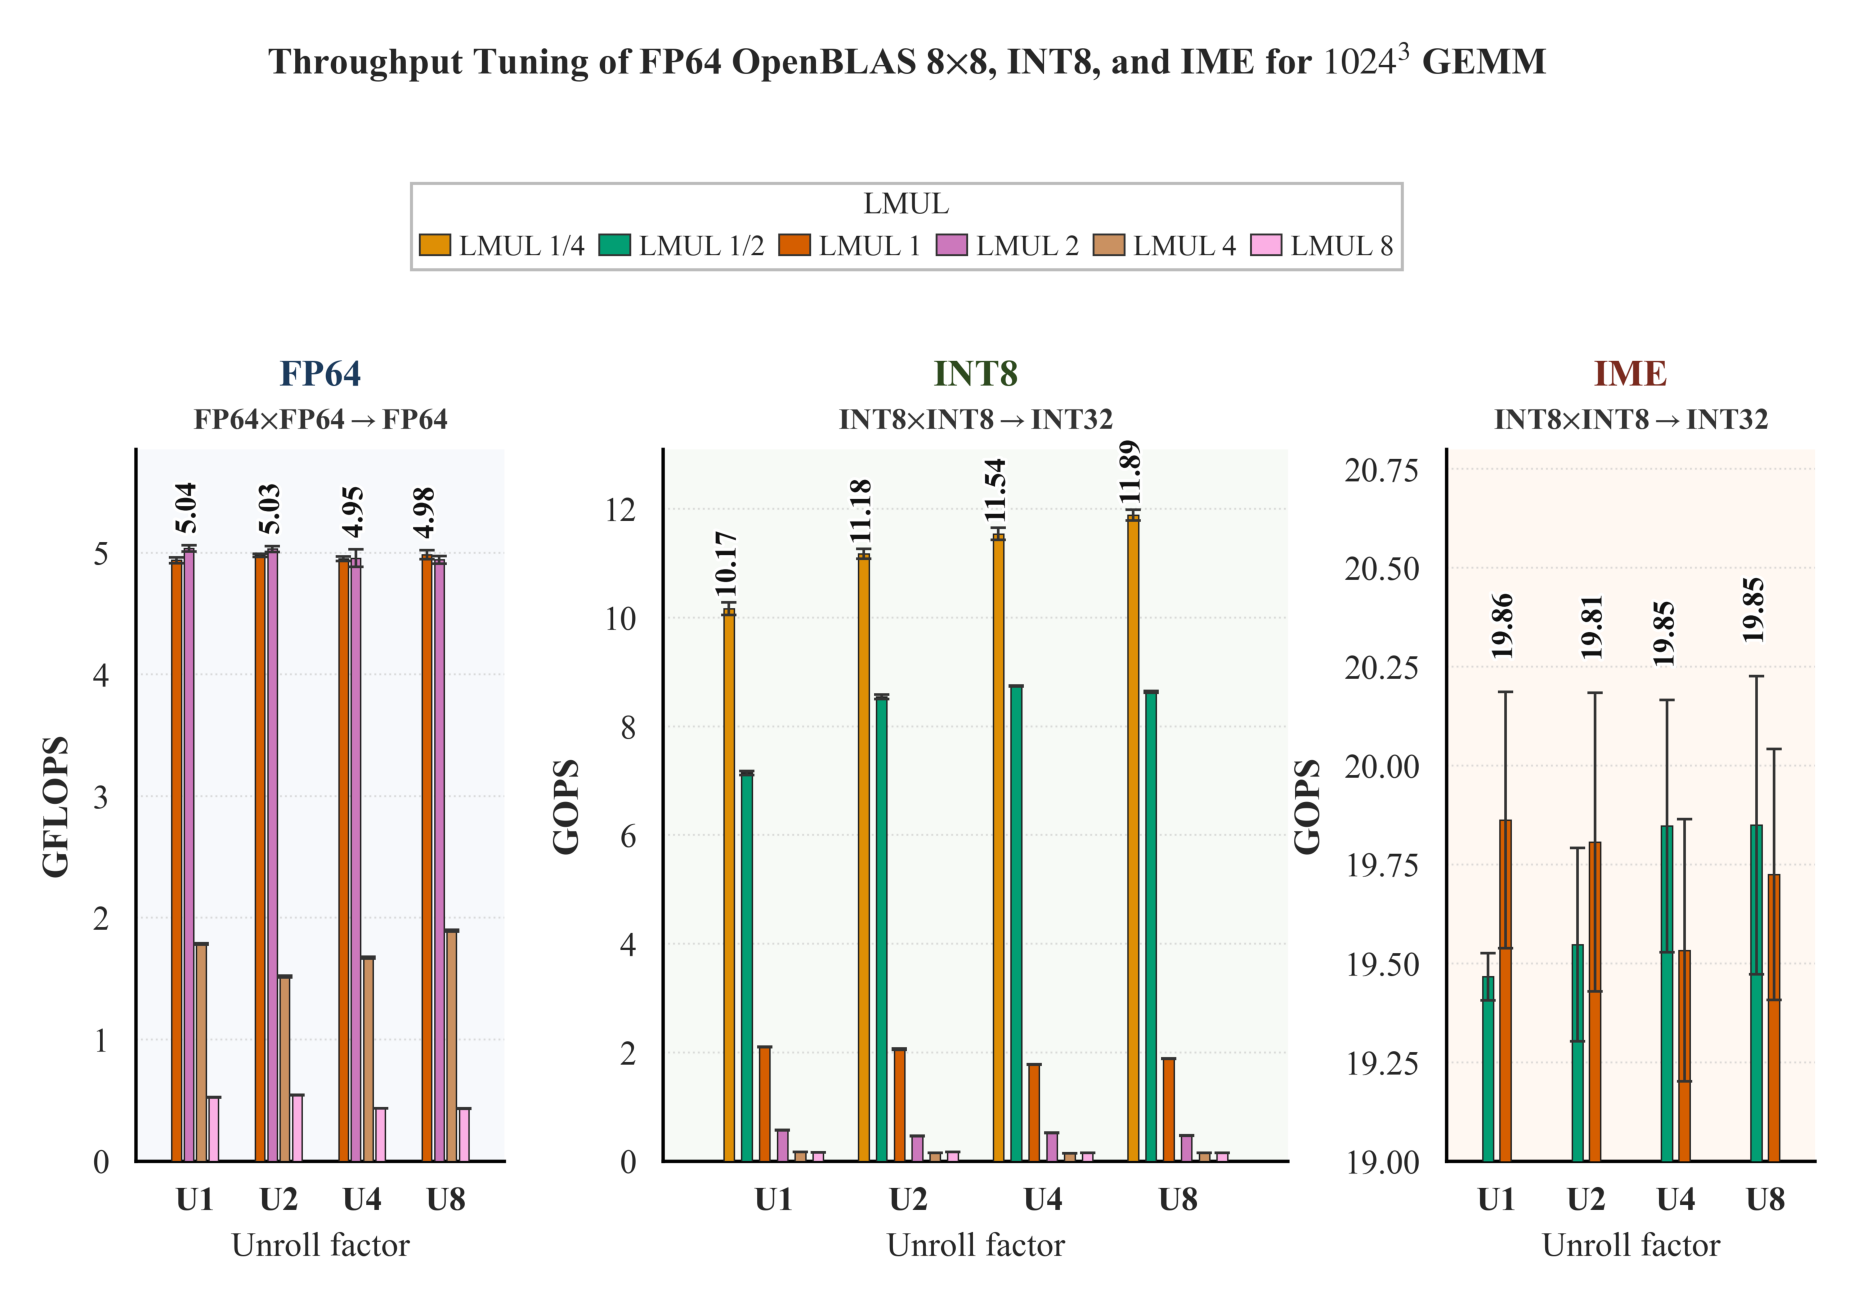

In [37]:
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.patheffects as pe
import seaborn as sns
from matplotlib.patches import Patch
from IPython.display import Image, display

# ─────────────────────────────────────────────────────────────
# Springer / publication style
# ─────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", context="paper")

matplotlib.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",

    "axes.linewidth": 0.90,
    "axes.edgecolor": "black",
    "axes.spines.top": False,
    "axes.spines.right": False,

    "xtick.major.width": 0.80,
    "ytick.major.width": 0.80,
    "xtick.major.size": 3.6,
    "ytick.major.size": 3.6,
    "xtick.direction": "out",
    "ytick.direction": "out",
})

# ─────────────────────────────────────────────────────────────
# Output
# ─────────────────────────────────────────────────────────────
OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

SAVE_PATH_PNG = os.path.join(
    OUTPUT_DIR,
    "fp64_8x8_int8_ime_1024_springer_polished_final.png"
)
SAVE_PATH_PDF = os.path.join(
    OUTPUT_DIR,
    "fp64_8x8_int8_ime_1024_springer_polished_final.pdf"
)

# ─────────────────────────────────────────────────────────────
# Data: FP64-INT8-IME Optimizations 8x8 Baseline, AI cluster 0–3
# ─────────────────────────────────────────────────────────────
DATA = [
    # FP64
    ("FP64", "1",   1, 4.937650, 0.023791),
    ("FP64", "1",   2, 4.979267, 0.012947),
    ("FP64", "1",   4, 4.950750, 0.019652),
    ("FP64", "1",   8, 4.984283, 0.037313),
    ("FP64", "2",   1, 5.036267, 0.025864),
    ("FP64", "2",   2, 5.031133, 0.023911),
    ("FP64", "2",   4, 4.954900, 0.072854),
    ("FP64", "2",   8, 4.941700, 0.031448),
    ("FP64", "4",   1, 1.784317, 0.005892),
    ("FP64", "4",   2, 1.515950, 0.007700),
    ("FP64", "4",   4, 1.672083, 0.007639),
    ("FP64", "4",   8, 1.895483, 0.007049),
    ("FP64", "8",   1, 0.525367, 0.001795),
    ("FP64", "8",   2, 0.542817, 0.000987),
    ("FP64", "8",   4, 0.435333, 0.000350),
    ("FP64", "8",   8, 0.433133, 0.001825),

    # INT8
    ("INT8", "mf4", 1, 10.166750, 0.114010),
    ("INT8", "mf4", 2, 11.176583, 0.089707),
    ("INT8", "mf4", 4, 11.543283, 0.108689),
    ("INT8", "mf4", 8, 11.888117, 0.101737),
    ("INT8", "mf2", 1, 7.143200, 0.039441),
    ("INT8", "mf2", 2, 8.545283, 0.038878),
    ("INT8", "mf2", 4, 8.743267, 0.008600),
    ("INT8", "mf2", 8, 8.636500, 0.019057),
    ("INT8", "1",   1, 2.100483, 0.004577),
    ("INT8", "1",   2, 2.060600, 0.008574),
    ("INT8", "1",   4, 1.782550, 0.004353),
    ("INT8", "1",   8, 1.888317, 0.002142),
    ("INT8", "2",   1, 0.572050, 0.001070),
    ("INT8", "2",   2, 0.464200, 0.000971),
    ("INT8", "2",   4, 0.523117, 0.001933),
    ("INT8", "2",   8, 0.471650, 0.000616),
    ("INT8", "4",   1, 0.166483, 0.000302),
    ("INT8", "4",   2, 0.149467, 0.000335),
    ("INT8", "4",   4, 0.144267, 0.000468),
    ("INT8", "4",   8, 0.151100, 0.000100),
    ("INT8", "8",   1, 0.164183, 0.000090),
    ("INT8", "8",   2, 0.168200, 0.000058),
    ("INT8", "8",   4, 0.151617, 0.000195),
    ("INT8", "8",   8, 0.149283, 0.000121),

    # IME
    ("IME",  "mf2", 1, 19.466717, 0.059715),
    ("IME",  "mf2", 2, 19.547750, 0.244230),
    ("IME",  "mf2", 4, 19.847400, 0.319252),
    ("IME",  "mf2", 8, 19.849917, 0.377000),
    ("IME",  "1",   1, 19.862017, 0.324074),
    ("IME",  "1",   2, 19.807100, 0.377561),
    ("IME",  "1",   4, 19.533267, 0.331679),
    ("IME",  "1",   8, 19.724450, 0.317294),
]

df = pd.DataFrame(DATA, columns=["Family", "LMUL", "Unroll", "Mean", "Std"])

# ─────────────────────────────────────────────────────────────
# Constants
# ─────────────────────────────────────────────────────────────
FAMILIES = ["FP64", "INT8", "IME"]
UNROLLS = [1, 2, 4, 8]
LMUL_ORDER = ["mf8", "mf4", "mf2", "1", "2", "4", "8"]

LMUL_LABEL = {
    "mf8": "LMUL 1/8",
    "mf4": "LMUL 1/4",
    "mf2": "LMUL 1/2",
    "1":   "LMUL 1",
    "2":   "LMUL 2",
    "4":   "LMUL 4",
    "8":   "LMUL 8",
}

palette = sns.color_palette("colorblind", 7)

LMUL_COLORS = {
    "mf8": palette[0],
    "mf4": palette[1],
    "mf2": palette[2],
    "1":   palette[3],
    "2":   palette[4],
    "4":   palette[5],
    "8":   palette[6],
}

FAMILY_FACE = {
    "FP64": "#F7F9FC",
    "INT8": "#F7FAF6",
    "IME":  "#FFF8F2",
}

FAMILY_ACCENT = {
    "FP64": "#1B3A5C",
    "INT8": "#2D4A1E",
    "IME":  "#7A2A1E",
}

FAMILY_SUBTITLE = {
    "FP64": r"FP64$\times$FP64$\rightarrow$FP64",
    "INT8": r"INT8$\times$INT8$\rightarrow$INT32",
    "IME":  r"INT8$\times$INT8$\rightarrow$INT32",
}

FAMILY_YLABEL = {
    "FP64": "GFLOPS",
    "INT8": "GOPS",
    "IME":  "GOPS",
}

UNROLL_LABEL = {
    1: "U1",
    2: "U2",
    4: "U4",
    8: "U8",
}

# Polished headroom for large labels
Y_LIMITS = {
    "FP64": (0.0, 5.85),
    "INT8": (0.0, 13.10),
    "IME":  (19.0, 20.80),
}

BAR_WIDTH = {
    "FP64": 0.115,
    "INT8": 0.078,
    "IME":  0.125,
}

GROUP_WIDTH = {
    "FP64": 0.56,
    "INT8": 0.74,
    "IME":  0.32,
}

LABEL_FONT = {
    "FP64": 8.0,
    "INT8": 8.0,
    "IME":  8.0,
}

CAPSIZE = 2.0

LABEL_Y_OFFSET = {
    "FP64": 0.090,
    "INT8": 0.080,
    "IME":  0.080,
}

# ─────────────────────────────────────────────────────────────
# Helpers
# ─────────────────────────────────────────────────────────────
def present_lmuls_for_family(fam):
    present = set(df.loc[df["Family"] == fam, "LMUL"])
    return [l for l in LMUL_ORDER if l in present]

def add_label(ax, x, y, text, fontsize):
    label = ax.text(
        x,
        y,
        text,
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=fontsize,
        fontweight="bold",
        color="#111111",
        zorder=9,
        clip_on=False,
    )
    label.set_path_effects([
        pe.Stroke(linewidth=1.6, foreground="white"),
        pe.Normal(),
    ])
    return label

# ─────────────────────────────────────────────────────────────
# Figure
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    1, 3,
    figsize=(6.8, 4.95),
    dpi=300,
    gridspec_kw={
        "width_ratios": [1.15, 1.95, 1.15],
        "wspace": 0.35,
    }
)

fig.suptitle(
    r"Throughput Tuning of FP64 OpenBLAS 8$\times$8, INT8, and IME for $1024^3$ GEMM",
    fontsize=10.0,
    fontweight="bold",
    y=0.970,
)

for ax, fam in zip(axes, FAMILIES):
    sub = df[df["Family"] == fam].copy()
    lmuls = present_lmuls_for_family(fam)

    x = np.arange(len(UNROLLS))
    total_width = GROUP_WIDTH[fam]
    bar_width = BAR_WIDTH[fam]

    offsets = np.linspace(
        -total_width / 2 + bar_width / 2,
         total_width / 2 - bar_width / 2,
        len(lmuls)
    )

    ax.set_facecolor(FAMILY_FACE[fam])
    bar_info = {}

    for offset, lmul in zip(offsets, lmuls):
        s = sub[sub["LMUL"] == lmul].set_index("Unroll").reindex(UNROLLS)
        vals = s["Mean"].values
        errs = s["Std"].values
        xpos = x + offset

        ax.bar(
            xpos,
            vals,
            width=bar_width,
            color=LMUL_COLORS[lmul],
            edgecolor="#222222",
            linewidth=0.38,
            yerr=errs,
            capsize=CAPSIZE,
            error_kw=dict(
                elinewidth=0.70,
                ecolor="#333333",
                capthick=0.70,
            ),
            zorder=3,
        )

        for i, u in enumerate(UNROLLS):
            bar_info[(lmul, u)] = {
                "x": xpos[i],
                "mean": vals[i],
                "std": errs[i],
                "lmul": lmul,
                "unroll": u,
            }

    # Label only the best value per unroll group
    for u in UNROLLS:
        records_u = [bar_info[(lmul, u)] for lmul in lmuls]
        best_rec = max(records_u, key=lambda r: r["mean"])

        add_label(
            ax,
            best_rec["x"],
            best_rec["mean"] + best_rec["std"] + LABEL_Y_OFFSET[fam],
            f"{best_rec['mean']:.2f}",
            LABEL_FONT[fam],
        )

    ax.set_title(
        fam,
        fontsize=10.0,
        fontweight="bold",
        color=FAMILY_ACCENT[fam],
        pad=17,
    )

    ax.text(
        0.5,
        1.020,
        FAMILY_SUBTITLE[fam],
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=8.0,
        fontweight="bold",
        color="#333333",
    )

    ax.set_xticks(x)
    ax.set_xticklabels(
        [UNROLL_LABEL[u] for u in UNROLLS],
        fontsize=9.0,
        fontweight="bold",
    )

    ax.set_xlabel("Unroll factor", fontsize=9.2, labelpad=4)
    ax.set_ylabel(
        FAMILY_YLABEL[fam],
        fontsize=9.6,
        fontweight="bold",
        labelpad=5,
    )

    ax.set_ylim(*Y_LIMITS[fam])
    ax.tick_params(axis="y", labelsize=9.0)

    ax.grid(
        axis="y",
        linestyle=":",
        linewidth=0.50,
        color="#C7C7C7",
        alpha=0.60,
        zorder=0,
    )
    ax.grid(False, axis="x")

    ax.set_axisbelow(True)
    ax.margins(x=0.12)

# ─────────────────────────────────────────────────────────────
# Legend
# ─────────────────────────────────────────────────────────────
present_lmuls = [l for l in LMUL_ORDER if l in set(df["LMUL"])]

legend_handles = [
    Patch(
        facecolor=LMUL_COLORS[l],
        edgecolor="#333333",
        linewidth=0.50,
        label=LMUL_LABEL[l],
    )
    for l in present_lmuls
]

fig.legend(
    handles=legend_handles,
    ncol=6,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.875),
    frameon=True,
    framealpha=1.0,
    fancybox=False,
    edgecolor="#BBBBBB",
    fontsize=7.8,
    title="LMUL",
    title_fontsize=8.2,
    borderpad=0.28,
    handlelength=1.05,
    handletextpad=0.30,
    columnspacing=0.48,
)

plt.subplots_adjust(
    left=0.080,
    right=0.995,
    bottom=0.132,
    top=0.665,
    wspace=0.35,
)

# ─────────────────────────────────────────────────────────────
# Save
# ─────────────────────────────────────────────────────────────
plt.savefig(SAVE_PATH_PNG, dpi=600, facecolor="white", bbox_inches="tight")
plt.savefig(SAVE_PATH_PDF, facecolor="white", bbox_inches="tight")

print(f"PNG: {os.path.abspath(SAVE_PATH_PNG)}")
print(f"PDF: {os.path.abspath(SAVE_PATH_PDF)}")

plt.close()

# ─────────────────────────────────────────────────────────────
# Notebook preview
# ─────────────────────────────────────────────────────────────
fig_preview, ax_preview = plt.subplots(figsize=(14, 8.5), dpi=150)
img = mpimg.imread(SAVE_PATH_PNG)
ax_preview.imshow(img)
ax_preview.axis("off")
plt.tight_layout(pad=0)
plt.show()

PNG: C:\Users\HP 850 G7\output\ime_acceleration_scalar_fallback_8x8_1024.png
PDF: C:\Users\HP 850 G7\output\ime_acceleration_scalar_fallback_8x8_1024.pdf


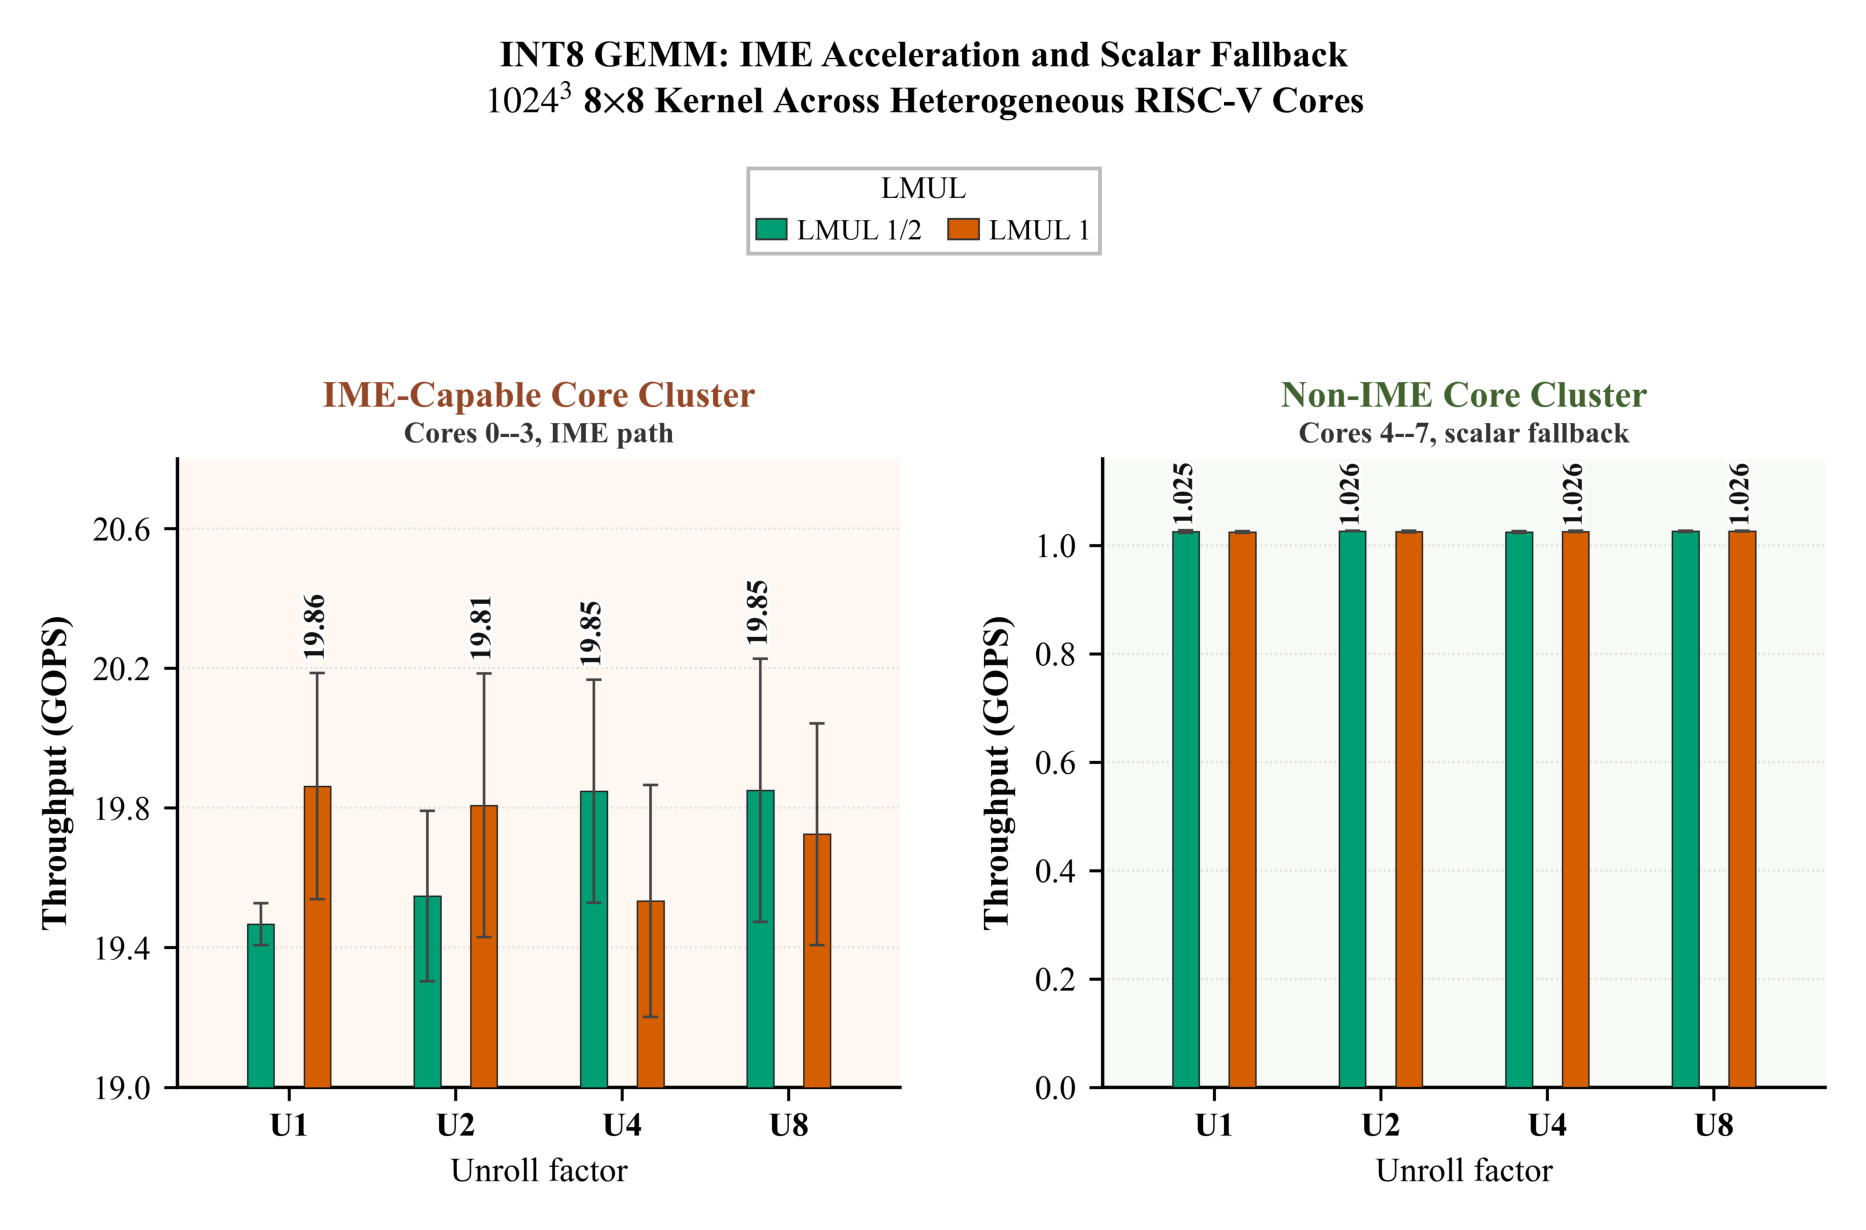

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.patheffects as pe
from matplotlib.patches import Patch

plt.close("all")

matplotlib.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "axes.linewidth": 0.90,
    "xtick.major.width": 0.80,
    "ytick.major.width": 0.80,
    "xtick.minor.width": 0.60,
    "ytick.minor.width": 0.60,
    "xtick.major.size": 3.6,
    "ytick.major.size": 3.6,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
})

OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

SAVE_PATH_PNG = os.path.join(
    OUTPUT_DIR,
    "ime_acceleration_scalar_fallback_8x8_1024.png"
)
SAVE_PATH_PDF = os.path.join(
    OUTPUT_DIR,
    "ime_acceleration_scalar_fallback_8x8_1024.pdf"
)

FIG_W, FIG_H = 6.8, 4.65
BAR_WIDTH = 0.16
GROUP_WIDTH = 0.34
CAPSIZE = 2.0

DATA = [
    ("IME-Capable Core Cluster", "1", 1, 19.8620166666667, 0.324074186037018),
    ("IME-Capable Core Cluster", "1", 2, 19.8071000000000, 0.377561169437042),
    ("IME-Capable Core Cluster", "1", 4, 19.5332666666667, 0.331679316341686),
    ("IME-Capable Core Cluster", "1", 8, 19.7244500000000, 0.317294278496582),

    ("IME-Capable Core Cluster", "mf2", 1, 19.4667166666667, 0.059715392115900),
    ("IME-Capable Core Cluster", "mf2", 2, 19.5477500000000, 0.244229733038383),
    ("IME-Capable Core Cluster", "mf2", 4, 19.8474000000000, 0.319252475845268),
    ("IME-Capable Core Cluster", "mf2", 8, 19.8499166666667, 0.376999546492507),

    ("Non-IME Core Cluster", "1", 1, 1.02450000000000, 0.001678292783357),
    ("Non-IME Core Cluster", "1", 2, 1.02555000000000, 0.001561783168902),
    ("Non-IME Core Cluster", "1", 4, 1.02573333333333, 0.001167142760001),
    ("Non-IME Core Cluster", "1", 8, 1.02603333333333, 0.000975818744554),

    ("Non-IME Core Cluster", "mf2", 1, 1.02541666666667, 0.002489589435139),
    ("Non-IME Core Cluster", "mf2", 2, 1.02645000000000, 0.000442530601578),
    ("Non-IME Core Cluster", "mf2", 4, 1.02461666666667, 0.001917825736493),
    ("Non-IME Core Cluster", "mf2", 8, 1.02591666666667, 0.001294110591187),
]

df = pd.DataFrame(DATA, columns=["Family", "LMUL", "Unroll", "Mean", "Std"])

FAMILIES = [
    "IME-Capable Core Cluster",
    "Non-IME Core Cluster",
]

UNROLLS = [1, 2, 4, 8]
LMUL_ORDER = ["mf2", "1"]

LMUL_LABEL = {
    "mf2": "LMUL 1/2",
    "1": "LMUL 1",
}

LMUL_COLORS = {
    "mf2": "#009E73",
    "1": "#D55E00",
}

FAMILY_FACE = {
    "IME-Capable Core Cluster": "#FFF8F2",
    "Non-IME Core Cluster": "#F7FAF6",
}

FAMILY_ACCENT = {
    "IME-Capable Core Cluster": "#944727",
    "Non-IME Core Cluster": "#41642F",
}

FAMILY_SUBTITLE = {
    "IME-Capable Core Cluster": "Cores 0--3, IME path",
    "Non-IME Core Cluster": "Cores 4--7, scalar fallback",
}

UNROLL_LABEL = {
    1: "U1",
    2: "U2",
    4: "U4",
    8: "U8",
}

Y_LIMITS = {
    "IME-Capable Core Cluster": (19.0, 20.80),
    "Non-IME Core Cluster": (0.0, 1.16),
}

Y_TICKS = {
    "IME-Capable Core Cluster": np.arange(19.0, 20.81, 0.4),
    "Non-IME Core Cluster": np.arange(0.0, 1.11, 0.2),
}

LABEL_FONT = {
    "IME-Capable Core Cluster": 8.0,
    "Non-IME Core Cluster": 7.6,
}

LABEL_Y_OFFSET = {
    "IME-Capable Core Cluster": 0.035,
    "Non-IME Core Cluster": 0.008,
}

VALUE_FORMAT = {
    "IME-Capable Core Cluster": "{:.2f}",
    "Non-IME Core Cluster": "{:.3f}",
}


def add_label(ax, x, y, text, fontsize):
    label = ax.text(
        x,
        y,
        text,
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=fontsize,
        fontweight="bold",
        color="#111111",
        zorder=8,
        clip_on=False,
    )
    label.set_path_effects([
        pe.Stroke(linewidth=1.60, foreground="white"),
        pe.Normal(),
    ])
    return label


fig, axes = plt.subplots(
    1, 2,
    figsize=(FIG_W, FIG_H),
    dpi=300,
    constrained_layout=False,
    gridspec_kw={
        "wspace": 0.28,
        "width_ratios": [1, 1],
    },
)

fig.patch.set_facecolor("white")

fig.suptitle(
    r"INT8 GEMM: IME Acceleration and Scalar Fallback"
    "\n"
    r"$1024^3$ 8$\times$8 Kernel Across Heterogeneous RISC-V Cores",
    fontsize=10.0,
    fontweight="bold",
    y=0.975,
)

for ax, fam in zip(axes, FAMILIES):
    sub = df[df["Family"] == fam].copy()
    lmuls = [l for l in LMUL_ORDER if l in set(sub["LMUL"])]

    x = np.arange(len(UNROLLS))
    offsets = np.linspace(-GROUP_WIDTH / 2, GROUP_WIDTH / 2, len(lmuls))

    ax.set_facecolor(FAMILY_FACE[fam])
    bar_info = {}

    for offset, lmul in zip(offsets, lmuls):
        s = sub[sub["LMUL"] == lmul].set_index("Unroll").reindex(UNROLLS)
        vals = s["Mean"].values
        errs = s["Std"].values
        xpos = x + offset

        ax.bar(
            xpos,
            vals,
            width=BAR_WIDTH,
            color=LMUL_COLORS[lmul],
            edgecolor="#222222",
            linewidth=0.38,
            yerr=errs,
            capsize=CAPSIZE,
            error_kw=dict(
                elinewidth=0.70,
                ecolor="#444444",
                capthick=0.70,
            ),
            zorder=3,
        )

        for i, u in enumerate(UNROLLS):
            bar_info[(lmul, u)] = {
                "x": xpos[i],
                "mean": vals[i],
                "std": errs[i],
            }

    for u in UNROLLS:
        records_u = [bar_info[(lmul, u)] for lmul in lmuls]
        best_rec = max(records_u, key=lambda r: r["mean"])

        add_label(
            ax=ax,
            x=best_rec["x"],
            y=best_rec["mean"] + best_rec["std"] + LABEL_Y_OFFSET[fam],
            text=VALUE_FORMAT[fam].format(best_rec["mean"]),
            fontsize=LABEL_FONT[fam],
        )

    ax.set_title(
        fam,
        fontsize=10.0,
        fontweight="bold",
        color=FAMILY_ACCENT[fam],
        pad=14,
    )

    ax.text(
        0.5,
        1.016,
        FAMILY_SUBTITLE[fam],
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=8.0,
        fontweight="bold",
        color="#333333",
    )

    ax.set_xticks(x)
    ax.set_xticklabels(
        [UNROLL_LABEL[u] for u in UNROLLS],
        fontsize=9.0,
        fontweight="bold",
    )

    ax.set_xlabel("Unroll factor", fontsize=9.2, labelpad=4)
    ax.set_ylabel(
        "Throughput (GOPS)",
        fontsize=9.6,
        fontweight="bold",
        labelpad=5,
    )

    ax.set_ylim(*Y_LIMITS[fam])
    ax.set_yticks(Y_TICKS[fam])

    ax.yaxis.grid(
        True,
        linestyle=":",
        linewidth=0.50,
        color="#C7C7C7",
        alpha=0.60,
        zorder=0,
    )
    ax.grid(False, axis="x")

    ax.set_axisbelow(True)
    ax.tick_params(axis="y", labelsize=9.0)
    ax.margins(x=0.12)

legend_handles = [
    Patch(
        facecolor=LMUL_COLORS[l],
        edgecolor="#333333",
        linewidth=0.50,
        label=LMUL_LABEL[l],
    )
    for l in LMUL_ORDER
]

fig.legend(
    handles=legend_handles,
    ncol=2,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.885),
    frameon=True,
    framealpha=1.0,
    fancybox=False,
    edgecolor="#BBBBBB",
    fontsize=7.8,
    title="LMUL",
    title_fontsize=8.2,
    borderpad=0.28,
    handlelength=1.05,
    handletextpad=0.35,
    columnspacing=0.90,
)

plt.subplots_adjust(
    left=0.090,
    right=0.995,
    bottom=0.135,
    top=0.640,
    wspace=0.28,
)

fig.savefig(SAVE_PATH_PNG, dpi=600, facecolor="white", bbox_inches="tight")
fig.savefig(SAVE_PATH_PDF, facecolor="white", bbox_inches="tight")

print(f"PNG: {os.path.abspath(SAVE_PATH_PNG)}")
print(f"PDF: {os.path.abspath(SAVE_PATH_PDF)}")

plt.close(fig)

fig_preview, ax_preview = plt.subplots(figsize=(13, 8.0), dpi=150)
img = mpimg.imread(SAVE_PATH_PNG)
ax_preview.imshow(img)
ax_preview.axis("off")
plt.tight_layout(pad=0)
plt.show()


PNG: C:\Users\HP 850 G7\output\fp32_8x4_int8_ime_fpint8_07_ime03_springer_polished_final.png
PDF: C:\Users\HP 850 G7\output\fp32_8x4_int8_ime_fpint8_07_ime03_springer_polished_final.pdf


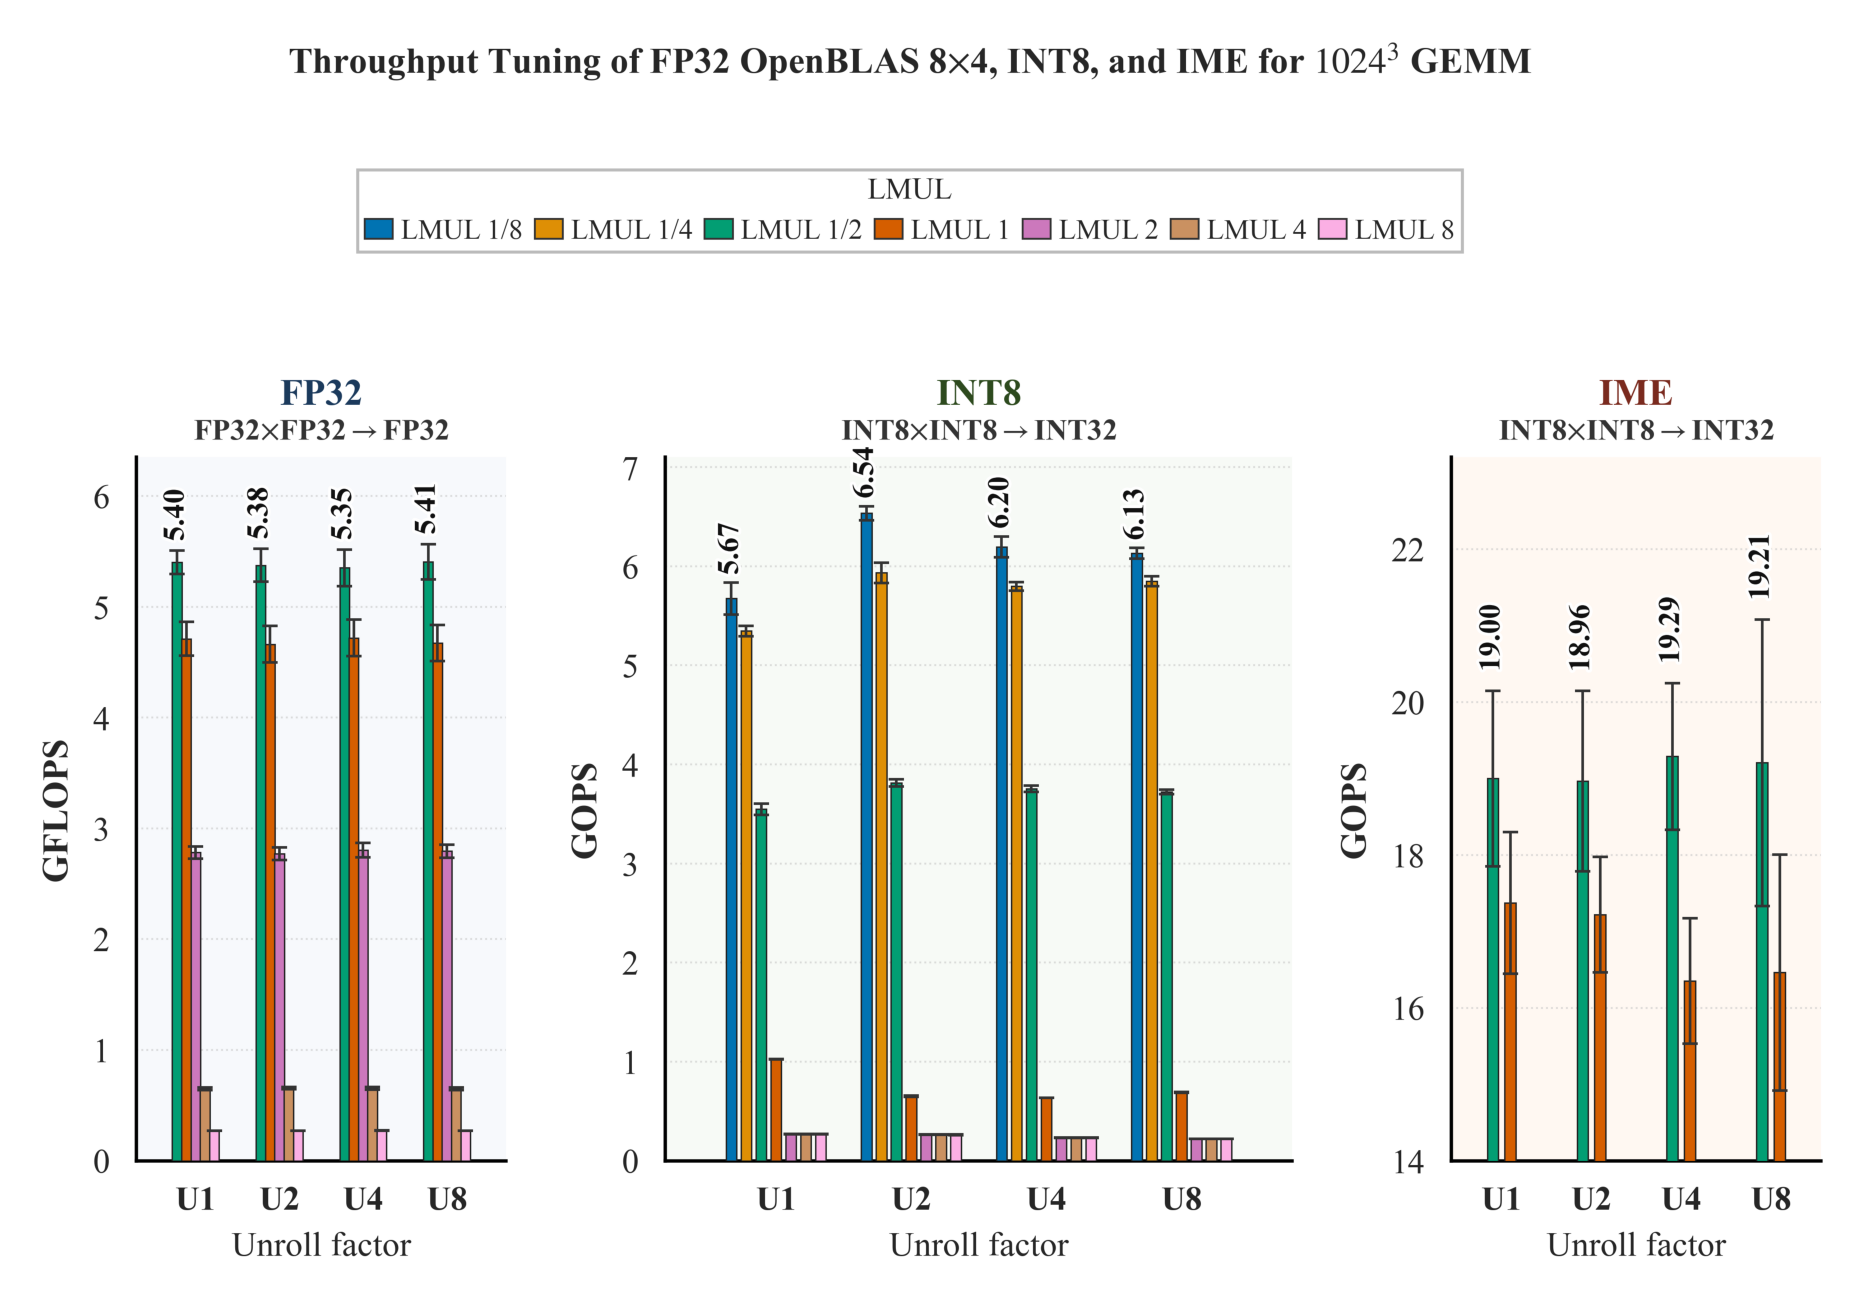

In [39]:
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.patheffects as pe
import seaborn as sns
from matplotlib.patches import Patch
from IPython.display import Image, display

# ─────────────────────────────────────────────────────────────
# Springer / publication style
# ─────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", context="paper")

matplotlib.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",

    "axes.linewidth": 0.90,
    "axes.edgecolor": "black",
    "axes.spines.top": False,
    "axes.spines.right": False,

    "xtick.major.width": 0.80,
    "ytick.major.width": 0.80,
    "xtick.major.size": 3.6,
    "ytick.major.size": 3.6,
    "xtick.direction": "out",
    "ytick.direction": "out",
})

# ─────────────────────────────────────────────────────────────
# Output
# ─────────────────────────────────────────────────────────────
OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

SAVE_PATH_PNG = os.path.join(
    OUTPUT_DIR,
    "fp32_8x4_int8_ime_fpint8_07_ime03_springer_polished_final.png"
)
SAVE_PATH_PDF = os.path.join(
    OUTPUT_DIR,
    "fp32_8x4_int8_ime_fpint8_07_ime03_springer_polished_final.pdf"
)

# ─────────────────────────────────────────────────────────────
# Data:
# FP32 + INT8 => combined from AI_0_3 + GP_4_6 (12 runs)
# IME        => AI_0_3 only (6 runs)
# ─────────────────────────────────────────────────────────────
DATA = [
    # FP32 (0-7 combined)
    ("FP32", "mf2", 1, 5.401608, 0.104930),
    ("FP32", "mf2", 2, 5.375408, 0.148089),
    ("FP32", "mf2", 4, 5.351608, 0.164669),
    ("FP32", "mf2", 8, 5.406058, 0.160169),
    ("FP32", "1",   1, 4.710558, 0.153040),
    ("FP32", "1",   2, 4.662825, 0.164479),
    ("FP32", "1",   4, 4.720025, 0.163007),
    ("FP32", "1",   8, 4.673150, 0.164505),
    ("FP32", "2",   1, 2.781567, 0.056917),
    ("FP32", "2",   2, 2.770883, 0.058179),
    ("FP32", "2",   4, 2.803492, 0.065272),
    ("FP32", "2",   8, 2.794683, 0.059546),
    ("FP32", "4",   1, 0.649158, 0.011361),
    ("FP32", "4",   2, 0.655900, 0.010241),
    ("FP32", "4",   4, 0.653375, 0.011860),
    ("FP32", "4",   8, 0.649717, 0.010963),
    ("FP32", "8",   1, 0.271550, 0.001278),
    ("FP32", "8",   2, 0.272167, 0.000236),
    ("FP32", "8",   4, 0.271175, 0.002258),
    ("FP32", "8",   8, 0.271583, 0.000657),

    # INT8 (0-7 combined)
    ("INT8", "mf8", 1, 5.674825, 0.161622),
    ("INT8", "mf8", 2, 6.535392, 0.071561),
    ("INT8", "mf8", 4, 6.195917, 0.105647),
    ("INT8", "mf8", 8, 6.130150, 0.055077),
    ("INT8", "mf4", 1, 5.347367, 0.051717),
    ("INT8", "mf4", 2, 5.933608, 0.103600),
    ("INT8", "mf4", 4, 5.797642, 0.042125),
    ("INT8", "mf4", 8, 5.849750, 0.049966),
    ("INT8", "mf2", 1, 3.548258, 0.055707),
    ("INT8", "mf2", 2, 3.813625, 0.036452),
    ("INT8", "mf2", 4, 3.753183, 0.030853),
    ("INT8", "mf2", 8, 3.723000, 0.023239),
    ("INT8", "1",   1, 1.025508, 0.001889),
    ("INT8", "1",   2, 0.649550, 0.006374),
    ("INT8", "1",   4, 0.635933, 0.000797),
    ("INT8", "1",   8, 0.689500, 0.005313),
    ("INT8", "2",   1, 0.269133, 0.001663),
    ("INT8", "2",   2, 0.263675, 0.003934),
    ("INT8", "2",   4, 0.232542, 0.003324),
    ("INT8", "2",   8, 0.222183, 0.000400),
    ("INT8", "4",   1, 0.269242, 0.001488),
    ("INT8", "4",   2, 0.263483, 0.003783),
    ("INT8", "4",   4, 0.232650, 0.003173),
    ("INT8", "4",   8, 0.222350, 0.000257),
    ("INT8", "8",   1, 0.269175, 0.001520),
    ("INT8", "8",   2, 0.263450, 0.004192),
    ("INT8", "8",   4, 0.232733, 0.003427),
    ("INT8", "8",   8, 0.222367, 0.000295),

    # IME (0-3 only)
    ("IME", "mf2", 1, 18.997733, 1.149666),
    ("IME", "mf2", 2, 18.963850, 1.179028),
    ("IME", "mf2", 4, 19.287100, 0.959838),
    ("IME", "mf2", 8, 19.205483, 1.872285),
    ("IME", "1",   1, 17.373050, 0.925108),
    ("IME", "1",   2, 17.217467, 0.756901),
    ("IME", "1",   4, 16.352000, 0.818898),
    ("IME", "1",   8, 16.461900, 1.542674),
]

df = pd.DataFrame(DATA, columns=["Family", "LMUL", "Unroll", "Mean", "Std"])

# ─────────────────────────────────────────────────────────────
# Constants
# ─────────────────────────────────────────────────────────────
FAMILIES = ["FP32", "INT8", "IME"]
UNROLLS = [1, 2, 4, 8]
LMUL_ORDER = ["mf8", "mf4", "mf2", "1", "2", "4", "8"]

LMUL_LABEL = {
    "mf8": "LMUL 1/8",
    "mf4": "LMUL 1/4",
    "mf2": "LMUL 1/2",
    "1":   "LMUL 1",
    "2":   "LMUL 2",
    "4":   "LMUL 4",
    "8":   "LMUL 8",
}

palette = sns.color_palette("colorblind", 7)

LMUL_COLORS = {
    "mf8": palette[0],
    "mf4": palette[1],
    "mf2": palette[2],
    "1":   palette[3],
    "2":   palette[4],
    "4":   palette[5],
    "8":   palette[6],
}

FAMILY_FACE = {
    "FP32": "#F7F9FC",
    "INT8": "#F7FAF6",
    "IME":  "#FFF8F2",
}

FAMILY_ACCENT = {
    "FP32": "#1B3A5C",
    "INT8": "#2D4A1E",
    "IME":  "#7A2A1E",
}

FAMILY_SUBTITLE = {
    "FP32": r"FP32$\times$FP32$\rightarrow$FP32",
    "INT8": r"INT8$\times$INT8$\rightarrow$INT32",
    "IME":  r"INT8$\times$INT8$\rightarrow$INT32",
}

FAMILY_YLABEL = {
    "FP32": "GFLOPS",
    "INT8": "GOPS",
    "IME":  "GOPS",
}

UNROLL_LABEL = {
    1: "U1",
    2: "U2",
    4: "U4",
    8: "U8",
}

Y_LIMITS = {
    "FP32": (0.0, 6.35),
    "INT8": (0.0, 7.10),
    "IME":  (14.0, 23.20),
}

BAR_WIDTH = {
    "FP32": 0.115,
    "INT8": 0.078,
    "IME":  0.125,
}

GROUP_WIDTH = {
    "FP32": 0.56,
    "INT8": 0.74,
    "IME":  0.32,
}

LABEL_FONT = {
    "FP32": 8.0,
    "INT8": 8.0,
    "IME":  8.0,
}

CAPSIZE = 2.0

LABEL_Y_OFFSET = {
    "FP32": 0.085,
    "INT8": 0.075,
    "IME":  0.25,
}

# ─────────────────────────────────────────────────────────────
# Helpers
# ─────────────────────────────────────────────────────────────
def present_lmuls_for_family(fam):
    present = set(df.loc[df["Family"] == fam, "LMUL"])
    return [l for l in LMUL_ORDER if l in present]

def add_label(ax, x, y, text, fontsize):
    label = ax.text(
        x,
        y,
        text,
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=fontsize,
        fontweight="bold",
        color="#111111",
        zorder=9,
        clip_on=False,
    )
    label.set_path_effects([
        pe.Stroke(linewidth=1.6, foreground="white"),
        pe.Normal(),
    ])
    return label

# ─────────────────────────────────────────────────────────────
# Figure
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    1, 3,
    figsize=(6.8, 4.95),
    dpi=300,
    gridspec_kw={
        "width_ratios": [1.15, 1.95, 1.15],
        "wspace": 0.35,
    }
)

fig.suptitle(
    r"Throughput Tuning of FP32 OpenBLAS 8$\times$4, INT8, and IME for $1024^3$ GEMM",
    fontsize=9.7,
    fontweight="bold",
    y=0.970,
)

for ax, fam in zip(axes, FAMILIES):
    sub = df[df["Family"] == fam].copy()
    lmuls = present_lmuls_for_family(fam)

    x = np.arange(len(UNROLLS))
    total_width = GROUP_WIDTH[fam]
    bar_width = BAR_WIDTH[fam]

    offsets = np.linspace(
        -total_width / 2 + bar_width / 2,
         total_width / 2 - bar_width / 2,
        len(lmuls)
    )

    ax.set_facecolor(FAMILY_FACE[fam])
    bar_info = {}

    for offset, lmul in zip(offsets, lmuls):
        s = sub[sub["LMUL"] == lmul].set_index("Unroll").reindex(UNROLLS)
        vals = s["Mean"].values
        errs = s["Std"].values
        xpos = x + offset

        ax.bar(
            xpos,
            vals,
            width=bar_width,
            color=LMUL_COLORS[lmul],
            edgecolor="#222222",
            linewidth=0.38,
            yerr=errs,
            capsize=CAPSIZE,
            error_kw=dict(
                elinewidth=0.70,
                ecolor="#333333",
                capthick=0.70,
            ),
            zorder=3,
        )

        for i, u in enumerate(UNROLLS):
            bar_info[(lmul, u)] = {
                "x": xpos[i],
                "mean": vals[i],
                "std": errs[i],
            }

    # Label only the best value per unroll group
    for u in UNROLLS:
        records_u = [bar_info[(lmul, u)] for lmul in lmuls]
        best_rec = max(records_u, key=lambda r: r["mean"])

        add_label(
            ax,
            best_rec["x"],
            best_rec["mean"] + best_rec["std"] + LABEL_Y_OFFSET[fam],
            f"{best_rec['mean']:.2f}",
            LABEL_FONT[fam],
        )

    ax.set_title(
        fam,
        fontsize=10.0,
        fontweight="bold",
        color=FAMILY_ACCENT[fam],
        pad=14,
    )

    ax.text(
        0.5,
        1.016,
        FAMILY_SUBTITLE[fam],
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=8.0,
        fontweight="bold",
        color="#333333",
    )

    ax.set_xticks(x)
    ax.set_xticklabels(
        [UNROLL_LABEL[u] for u in UNROLLS],
        fontsize=9.0,
        fontweight="bold",
    )

    ax.set_xlabel("Unroll factor", fontsize=9.2, labelpad=4)
    ax.set_ylabel(
        FAMILY_YLABEL[fam],
        fontsize=9.6,
        fontweight="bold",
        labelpad=5,
    )

    ax.set_ylim(*Y_LIMITS[fam])
    ax.tick_params(axis="y", labelsize=9.0)

    ax.grid(
        axis="y",
        linestyle=":",
        linewidth=0.50,
        color="#C7C7C7",
        alpha=0.60,
        zorder=0,
    )
    ax.grid(False, axis="x")

    ax.set_axisbelow(True)
    ax.margins(x=0.12)

# ─────────────────────────────────────────────────────────────
# Legend
# ─────────────────────────────────────────────────────────────
present_lmuls = [l for l in LMUL_ORDER if l in set(df["LMUL"])]

legend_handles = [
    Patch(
        facecolor=LMUL_COLORS[l],
        edgecolor="#333333",
        linewidth=0.50,
        label=LMUL_LABEL[l],
    )
    for l in present_lmuls
]

fig.legend(
    handles=legend_handles,
    ncol=7,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.885),
    frameon=True,
    framealpha=1.0,
    fancybox=False,
    edgecolor="#BBBBBB",
    fontsize=7.5,
    title="LMUL",
    title_fontsize=8.0,
    borderpad=0.26,
    handlelength=1.00,
    handletextpad=0.28,
    columnspacing=0.42,
)

plt.subplots_adjust(
    left=0.080,
    right=0.995,
    bottom=0.135,
    top=0.660,
    wspace=0.35,
)

# ─────────────────────────────────────────────────────────────
# Save
# ─────────────────────────────────────────────────────────────
plt.savefig(SAVE_PATH_PNG, dpi=600, facecolor="white", bbox_inches="tight")
plt.savefig(SAVE_PATH_PDF, facecolor="white", bbox_inches="tight")

print(f"PNG: {os.path.abspath(SAVE_PATH_PNG)}")
print(f"PDF: {os.path.abspath(SAVE_PATH_PDF)}")

plt.close()

# ─────────────────────────────────────────────────────────────
# Notebook preview
# ─────────────────────────────────────────────────────────────
fig_preview, ax_preview = plt.subplots(figsize=(14, 8.5), dpi=150)
img = mpimg.imread(SAVE_PATH_PNG)
ax_preview.imshow(img)
ax_preview.axis("off")
plt.tight_layout(pad=0)
plt.show()


PNG: C:\Users\HP 850 G7\output\ime_acceleration_scalar_fallback_fp32_8x4_1024.png
PDF: C:\Users\HP 850 G7\output\ime_acceleration_scalar_fallback_fp32_8x4_1024.pdf


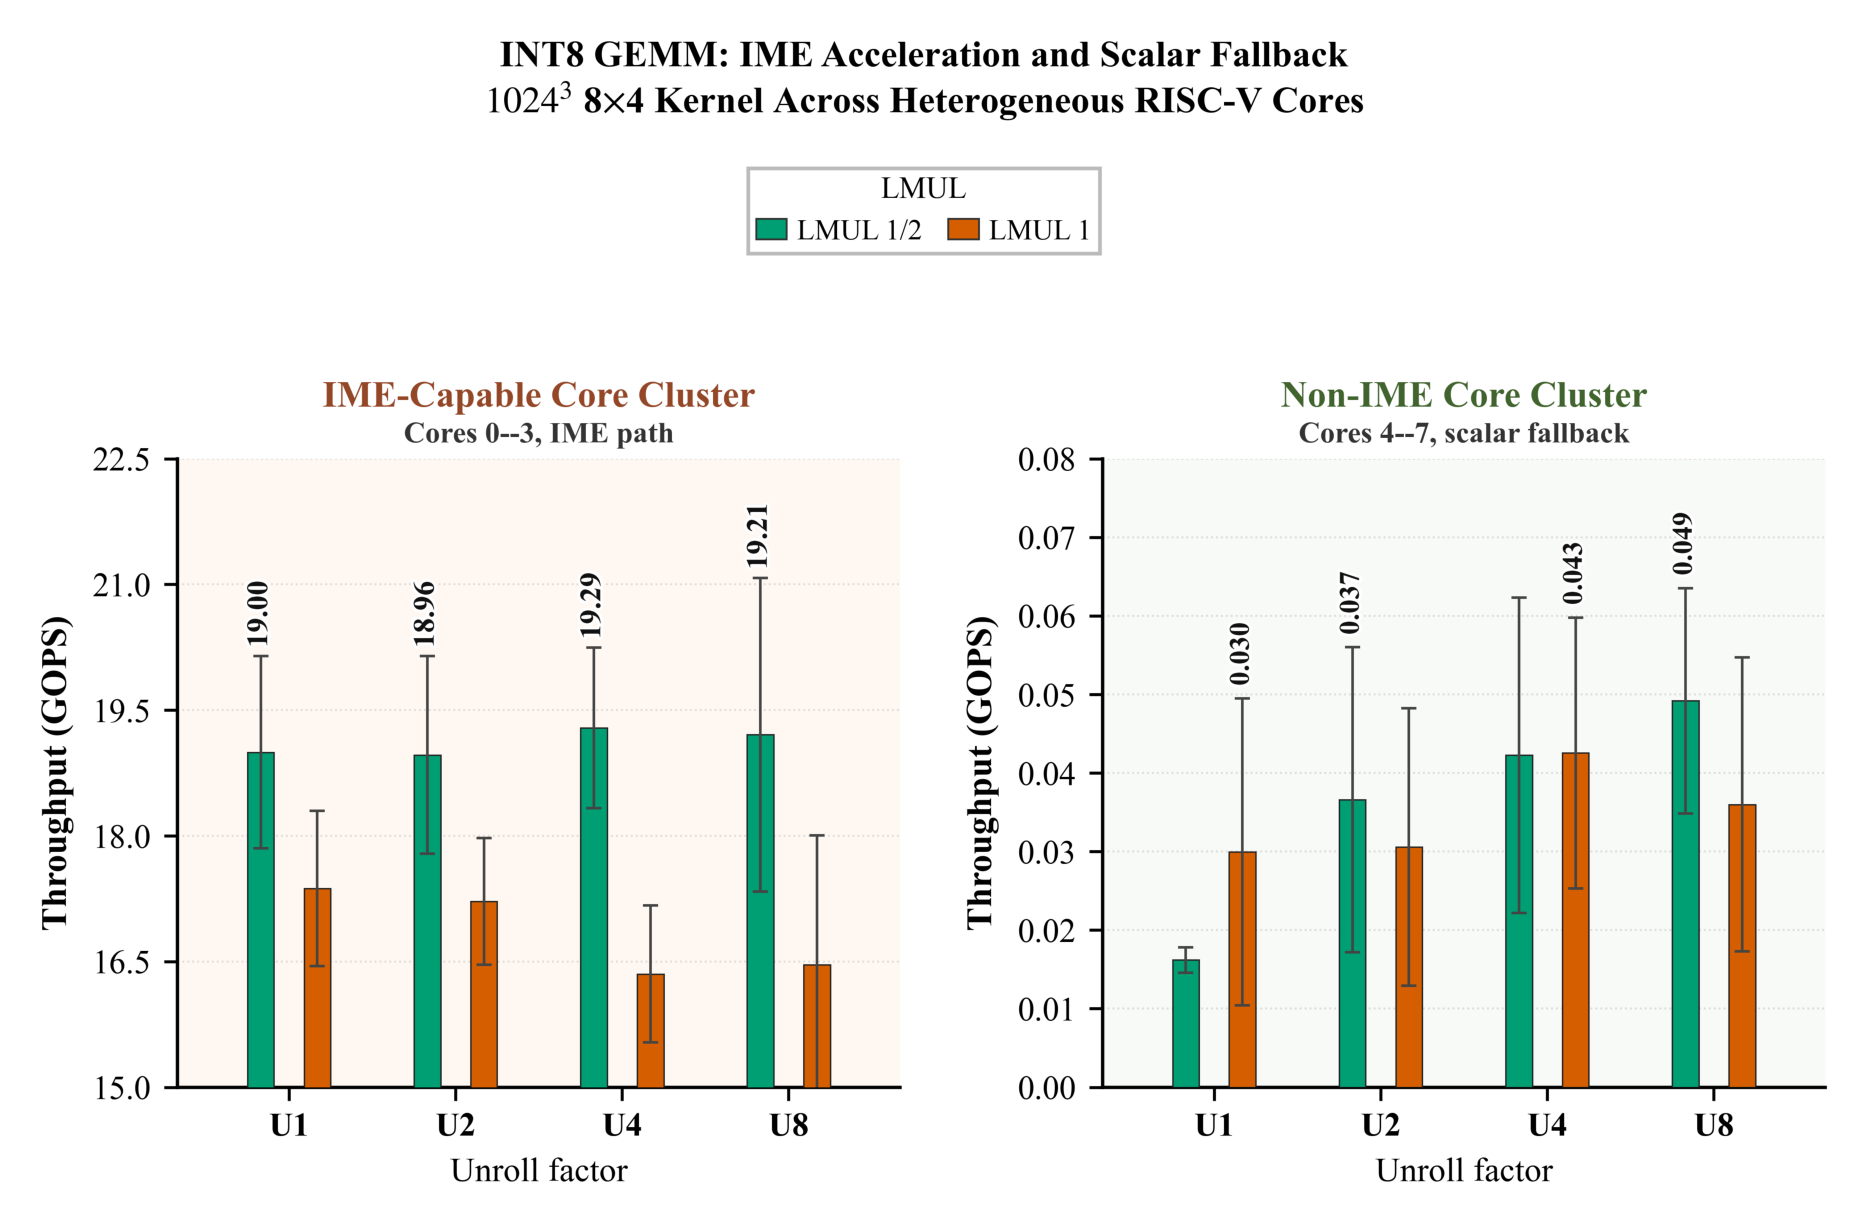

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.patheffects as pe
from matplotlib.patches import Patch

plt.close("all")

matplotlib.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "axes.linewidth": 0.90,
    "xtick.major.width": 0.80,
    "ytick.major.width": 0.80,
    "xtick.minor.width": 0.60,
    "ytick.minor.width": 0.60,
    "xtick.major.size": 3.6,
    "ytick.major.size": 3.6,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
})

OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

SAVE_PATH_PNG = os.path.join(
    OUTPUT_DIR,
    "ime_acceleration_scalar_fallback_fp32_8x4_1024.png"
)
SAVE_PATH_PDF = os.path.join(
    OUTPUT_DIR,
    "ime_acceleration_scalar_fallback_fp32_8x4_1024.pdf"
)

FIG_W, FIG_H = 6.8, 4.65
BAR_WIDTH = 0.16
GROUP_WIDTH = 0.34
CAPSIZE = 2.0

DATA = [
    ("IME-Capable Core Cluster", "1", 1, 17.373050000000, 0.925107978833),
    ("IME-Capable Core Cluster", "1", 2, 17.217466666667, 0.756900587190),
    ("IME-Capable Core Cluster", "1", 4, 16.352000000000, 0.818897516991),
    ("IME-Capable Core Cluster", "1", 8, 16.461900000000, 1.542673804363),

    ("IME-Capable Core Cluster", "mf2", 1, 18.997733333333, 1.149666336619),
    ("IME-Capable Core Cluster", "mf2", 2, 18.963850000000, 1.179027563644),
    ("IME-Capable Core Cluster", "mf2", 4, 19.287100000000, 0.959837672040),
    ("IME-Capable Core Cluster", "mf2", 8, 19.205483333333, 1.872285032980),

    ("Non-IME Core Cluster", "1", 1, 0.029966666667, 0.019533276450),
    ("Non-IME Core Cluster", "1", 2, 0.030583333333, 0.017666674528),
    ("Non-IME Core Cluster", "1", 4, 0.042550000000, 0.017232116334),
    ("Non-IME Core Cluster", "1", 8, 0.035983333333, 0.018701373984),

    ("Non-IME Core Cluster", "mf2", 1, 0.016183333333, 0.001591033906),
    ("Non-IME Core Cluster", "mf2", 2, 0.036583333333, 0.019404330845),
    ("Non-IME Core Cluster", "mf2", 4, 0.042250000000, 0.020076250480),
    ("Non-IME Core Cluster", "mf2", 8, 0.049200000000, 0.014336550027),
]

df = pd.DataFrame(DATA, columns=["Family", "LMUL", "Unroll", "Mean", "Std"])

FAMILIES = [
    "IME-Capable Core Cluster",
    "Non-IME Core Cluster",
]

UNROLLS = [1, 2, 4, 8]
LMUL_ORDER = ["mf2", "1"]

LMUL_LABEL = {
    "mf2": "LMUL 1/2",
    "1": "LMUL 1",
}

LMUL_COLORS = {
    "mf2": "#009E73",
    "1": "#D55E00",
}

FAMILY_FACE = {
    "IME-Capable Core Cluster": "#FFF8F2",
    "Non-IME Core Cluster": "#F7FAF6",
}

FAMILY_ACCENT = {
    "IME-Capable Core Cluster": "#944727",
    "Non-IME Core Cluster": "#41642F",
}

FAMILY_SUBTITLE = {
    "IME-Capable Core Cluster": "Cores 0--3, IME path",
    "Non-IME Core Cluster": "Cores 4--7, scalar fallback",
}

UNROLL_LABEL = {
    1: "U1",
    2: "U2",
    4: "U4",
    8: "U8",
}

Y_LIMITS = {
    "IME-Capable Core Cluster": (15.0, 22.5),
    "Non-IME Core Cluster": (0.0, 0.080),
}

Y_TICKS = {
    "IME-Capable Core Cluster": np.arange(15.0, 22.6, 1.5),
    "Non-IME Core Cluster": np.arange(0.0, 0.081, 0.01),
}

LABEL_FONT = {
    "IME-Capable Core Cluster": 8.0,
    "Non-IME Core Cluster": 7.6,
}

LABEL_Y_OFFSET = {
    "IME-Capable Core Cluster": 0.10,
    "Non-IME Core Cluster": 0.0016,
}

VALUE_FORMAT = {
    "IME-Capable Core Cluster": "{:.2f}",
    "Non-IME Core Cluster": "{:.3f}",
}


def add_label(ax, x, y, text, fontsize):
    label = ax.text(
        x,
        y,
        text,
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=fontsize,
        fontweight="bold",
        color="#111111",
        zorder=8,
        clip_on=False,
    )
    label.set_path_effects([
        pe.Stroke(linewidth=1.60, foreground="white"),
        pe.Normal(),
    ])
    return label


fig, axes = plt.subplots(
    1, 2,
    figsize=(FIG_W, FIG_H),
    dpi=300,
    constrained_layout=False,
    gridspec_kw={"wspace": 0.28, "width_ratios": [1, 1]},
)

fig.patch.set_facecolor("white")

fig.suptitle(
    r"INT8 GEMM: IME Acceleration and Scalar Fallback"
    "\n"
    r"$1024^3$ 8$\times$4 Kernel Across Heterogeneous RISC-V Cores",
    fontsize=10.0,
    fontweight="bold",
    y=0.975,
)

for ax, fam in zip(axes, FAMILIES):
    sub = df[df["Family"] == fam].copy()
    lmuls = [l for l in LMUL_ORDER if l in set(sub["LMUL"])]

    x = np.arange(len(UNROLLS))
    offsets = np.linspace(-GROUP_WIDTH / 2, GROUP_WIDTH / 2, len(lmuls))

    ax.set_facecolor(FAMILY_FACE[fam])
    bar_info = {}

    for offset, lmul in zip(offsets, lmuls):
        s = sub[sub["LMUL"] == lmul].set_index("Unroll").reindex(UNROLLS)
        vals = s["Mean"].values
        errs = s["Std"].values
        xpos = x + offset

        ax.bar(
            xpos,
            vals,
            width=BAR_WIDTH,
            color=LMUL_COLORS[lmul],
            edgecolor="#222222",
            linewidth=0.38,
            yerr=errs,
            capsize=CAPSIZE,
            error_kw=dict(elinewidth=0.70, ecolor="#444444", capthick=0.70),
            zorder=3,
        )

        for i, u in enumerate(UNROLLS):
            bar_info[(lmul, u)] = {
                "x": xpos[i],
                "mean": vals[i],
                "std": errs[i],
            }

    for u in UNROLLS:
        records_u = [bar_info[(lmul, u)] for lmul in lmuls]
        best_rec = max(records_u, key=lambda r: r["mean"])

        add_label(
            ax=ax,
            x=best_rec["x"],
            y=best_rec["mean"] + best_rec["std"] + LABEL_Y_OFFSET[fam],
            text=VALUE_FORMAT[fam].format(best_rec["mean"]),
            fontsize=LABEL_FONT[fam],
        )

    ax.set_title(
        fam,
        fontsize=10.0,
        fontweight="bold",
        color=FAMILY_ACCENT[fam],
        pad=14,
    )

    ax.text(
        0.5,
        1.016,
        FAMILY_SUBTITLE[fam],
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=8.0,
        fontweight="bold",
        color="#333333",
    )

    ax.set_xticks(x)
    ax.set_xticklabels(
        [UNROLL_LABEL[u] for u in UNROLLS],
        fontsize=9.0,
        fontweight="bold",
    )

    ax.set_xlabel("Unroll factor", fontsize=9.2, labelpad=4)
    ax.set_ylabel(
        "Throughput (GOPS)",
        fontsize=9.6,
        fontweight="bold",
        labelpad=5,
    )

    ax.set_ylim(*Y_LIMITS[fam])
    ax.set_yticks(Y_TICKS[fam])

    ax.yaxis.grid(
        True,
        linestyle=":",
        linewidth=0.50,
        color="#C7C7C7",
        alpha=0.60,
        zorder=0,
    )
    ax.grid(False, axis="x")
    ax.set_axisbelow(True)
    ax.tick_params(axis="y", labelsize=9.0)
    ax.margins(x=0.12)

legend_handles = [
    Patch(
        facecolor=LMUL_COLORS[l],
        edgecolor="#333333",
        linewidth=0.50,
        label=LMUL_LABEL[l],
    )
    for l in LMUL_ORDER
]

fig.legend(
    handles=legend_handles,
    ncol=2,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.885),
    frameon=True,
    framealpha=1.0,
    fancybox=False,
    edgecolor="#BBBBBB",
    fontsize=7.8,
    title="LMUL",
    title_fontsize=8.2,
    borderpad=0.28,
    handlelength=1.05,
    handletextpad=0.35,
    columnspacing=0.90,
)

plt.subplots_adjust(left=0.090, right=0.995, bottom=0.135, top=0.640, wspace=0.28)

fig.savefig(SAVE_PATH_PNG, dpi=600, facecolor="white", bbox_inches="tight")
fig.savefig(SAVE_PATH_PDF, facecolor="white", bbox_inches="tight")

print(f"PNG: {os.path.abspath(SAVE_PATH_PNG)}")
print(f"PDF: {os.path.abspath(SAVE_PATH_PDF)}")

plt.close(fig)

fig_preview, ax_preview = plt.subplots(figsize=(13, 8.0), dpi=150)
img = mpimg.imread(SAVE_PATH_PNG)
ax_preview.imshow(img)
ax_preview.axis("off")
plt.tight_layout(pad=0)
plt.show()


PNG: C:\Users\HP 850 G7\output\fp32_8x8_plot1_fp_int8_07_ime03.png
PDF: C:\Users\HP 850 G7\output\fp32_8x8_plot1_fp_int8_07_ime03.pdf


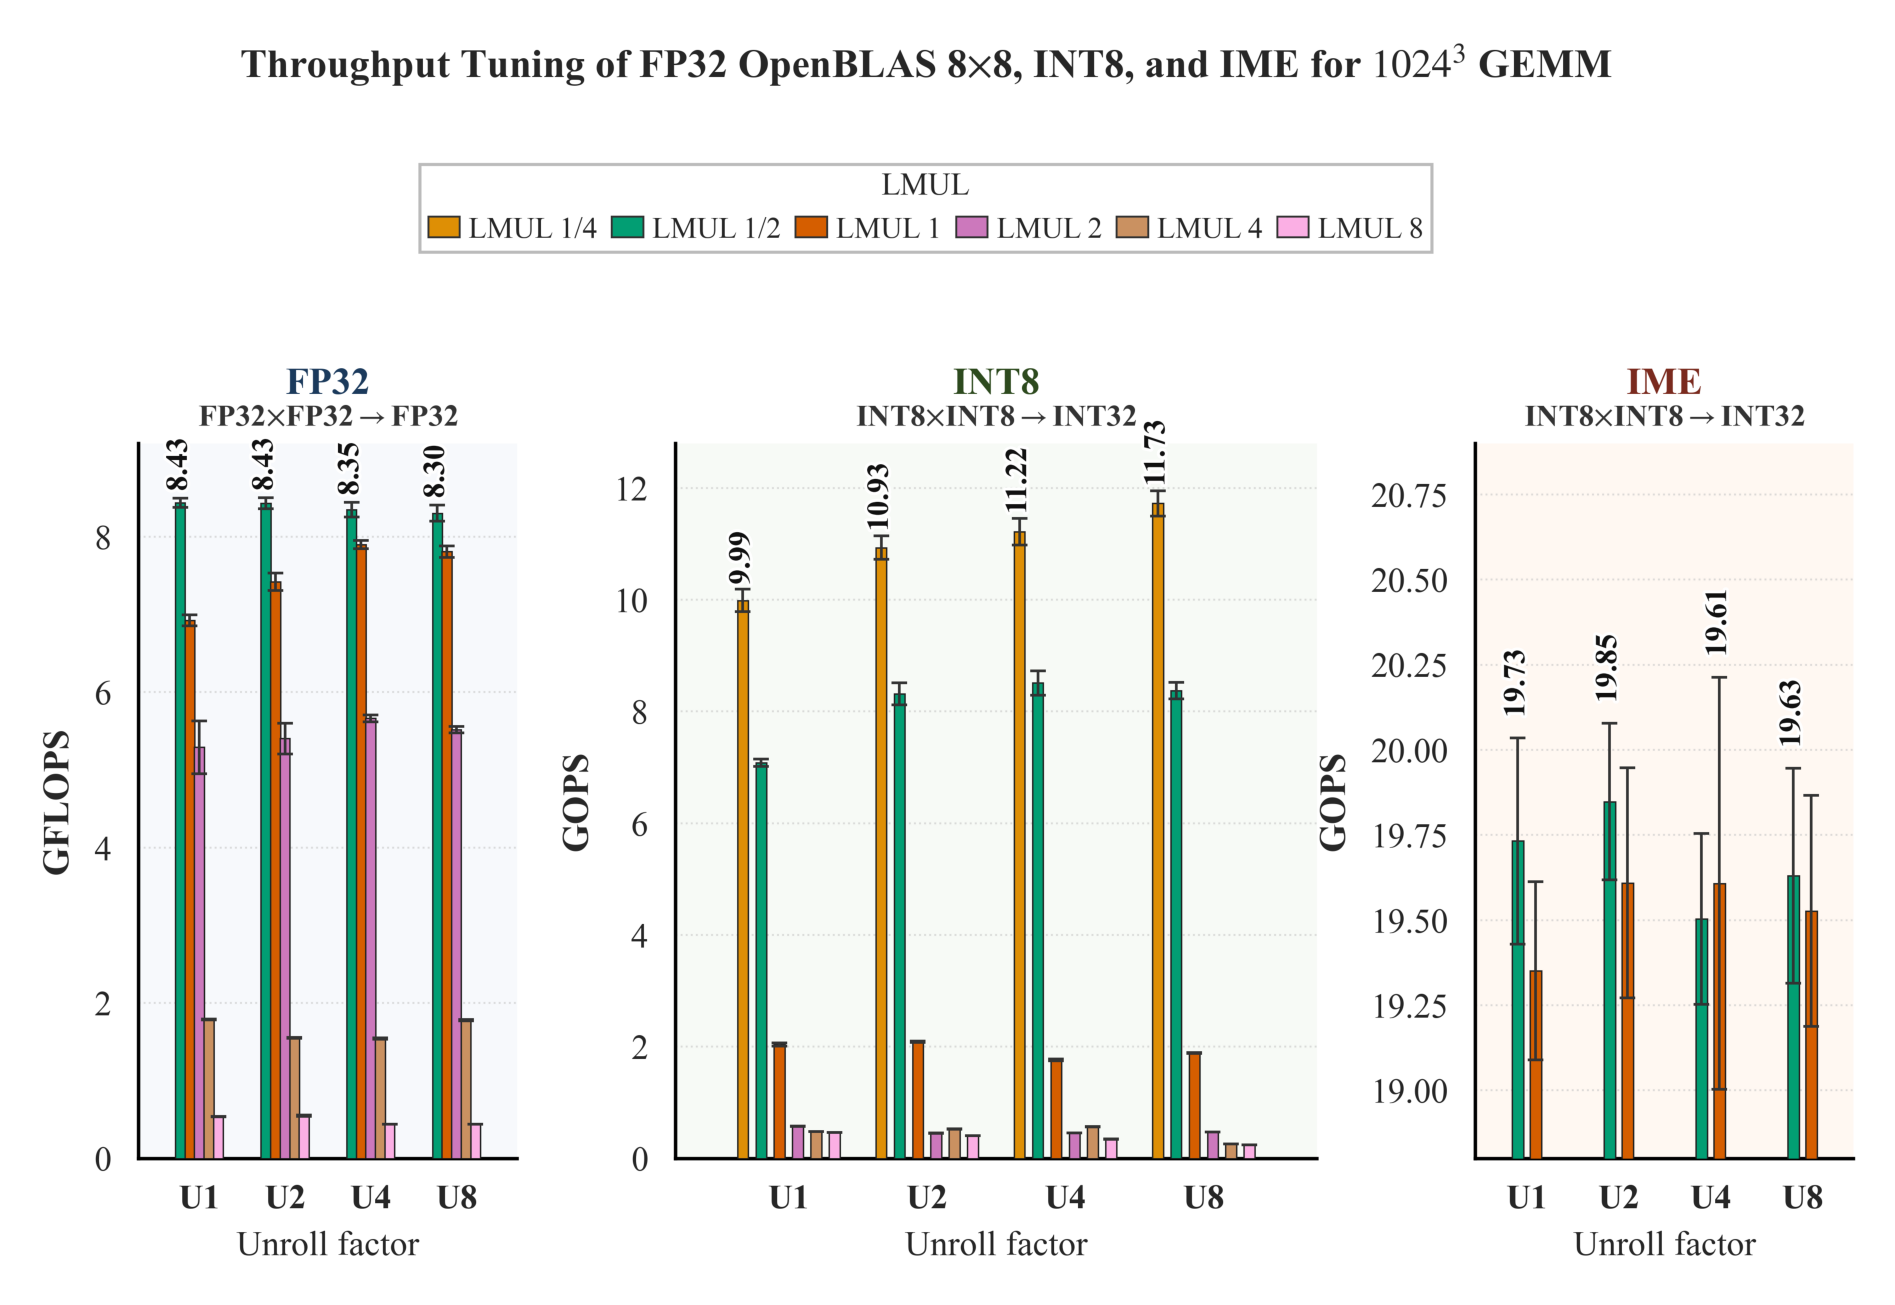

In [41]:
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.patheffects as pe
import seaborn as sns
from matplotlib.patches import Patch
from IPython.display import Image, display

# ─────────────────────────────────────────────────────────────
# Springer / publication style
# ─────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", context="paper")

matplotlib.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",

    "axes.linewidth": 0.90,
    "axes.edgecolor": "black",
    "axes.spines.top": False,
    "axes.spines.right": False,

    "xtick.major.width": 0.80,
    "ytick.major.width": 0.80,
    "xtick.major.size": 3.6,
    "ytick.major.size": 3.6,
    "xtick.direction": "out",
    "ytick.direction": "out",
})

# ─────────────────────────────────────────────────────────────
# Output
# ─────────────────────────────────────────────────────────────
OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

SAVE_PATH_PNG = os.path.join(OUTPUT_DIR, "fp32_8x8_plot1_fp_int8_07_ime03.png")
SAVE_PATH_PDF = os.path.join(OUTPUT_DIR, "fp32_8x8_plot1_fp_int8_07_ime03.pdf")

# ─────────────────────────────────────────────────────────────
# Data
# FP32 + INT8: combined (AI_0_3 + GP_4_6) => 12 runs per point
# IME: AI_0_3 only => 6 runs per point
# ─────────────────────────────────────────────────────────────
DATA = [
    # FP32 (0-7 style combined)
    ("FP32", "mf2", 1, 8.434933, 0.060914),
    ("FP32", "mf2", 2, 8.428925, 0.070869),
    ("FP32", "mf2", 4, 8.346642, 0.092569),
    ("FP32", "mf2", 8, 8.301742, 0.102743),
    ("FP32", "1",   1, 6.922642, 0.073557),
    ("FP32", "1",   2, 7.418692, 0.111078),
    ("FP32", "1",   4, 7.897333, 0.050922),
    ("FP32", "1",   8, 7.806767, 0.075439),
    ("FP32", "2",   1, 5.290725, 0.339747),
    ("FP32", "2",   2, 5.401858, 0.199787),
    ("FP32", "2",   4, 5.662992, 0.043692),
    ("FP32", "2",   8, 5.518083, 0.040699),
    ("FP32", "4",   1, 1.788767, 0.006627),
    ("FP32", "4",   2, 1.552742, 0.006471),
    ("FP32", "4",   4, 1.542325, 0.009257),
    ("FP32", "4",   8, 1.778150, 0.007745),
    ("FP32", "8",   1, 0.537700, 0.004657),
    ("FP32", "8",   2, 0.548717, 0.008424),
    ("FP32", "8",   4, 0.440525, 0.000970),
    ("FP32", "8",   8, 0.442300, 0.000115),

    # INT8 (0-7 style combined)
    ("INT8", "mf4", 1, 9.989383, 0.202974),
    ("INT8", "mf4", 2, 10.933517, 0.211775),
    ("INT8", "mf4", 4, 11.215458, 0.238233),
    ("INT8", "mf4", 8, 11.725600, 0.224237),
    ("INT8", "mf2", 1, 7.081750, 0.067118),
    ("INT8", "mf2", 2, 8.318742, 0.196845),
    ("INT8", "mf2", 4, 8.510500, 0.216729),
    ("INT8", "mf2", 8, 8.377425, 0.147673),
    ("INT8", "1",   1, 2.042108, 0.028565),
    ("INT8", "1",   2, 2.086558, 0.011150),
    ("INT8", "1",   4, 1.761133, 0.017016),
    ("INT8", "1",   8, 1.888042, 0.005687),
    ("INT8", "2",   1, 0.578092, 0.002660),
    ("INT8", "2",   2, 0.450500, 0.002068),
    ("INT8", "2",   4, 0.456192, 0.001449),
    ("INT8", "2",   8, 0.472267, 0.001599),
    ("INT8", "4",   1, 0.480950, 0.001517),
    ("INT8", "4",   2, 0.525983, 0.007086),
    ("INT8", "4",   4, 0.566817, 0.003803),
    ("INT8", "4",   8, 0.259450, 0.000233),
    ("INT8", "8",   1, 0.462867, 0.001867),
    ("INT8", "8",   2, 0.406742, 0.001063),
    ("INT8", "8",   4, 0.345817, 0.001106),
    ("INT8", "8",   8, 0.241958, 0.000487),

    # IME (AI_0_3 only)
    ("IME",  "mf2", 1, 19.732117, 0.302594),
    ("IME",  "mf2", 2, 19.847650, 0.230171),
    ("IME",  "mf2", 4, 19.503700, 0.251126),
    ("IME",  "mf2", 8, 19.630217, 0.315946),
    ("IME",  "1",   1, 19.351283, 0.261821),
    ("IME",  "1",   2, 19.609300, 0.338378),
    ("IME",  "1",   4, 19.607717, 0.605231),
    ("IME",  "1",   8, 19.526867, 0.338955),
]

df = pd.DataFrame(DATA, columns=["Family", "LMUL", "Unroll", "Mean", "Std"])

# ─────────────────────────────────────────────────────────────
# Constants
# ─────────────────────────────────────────────────────────────
FAMILIES = ["FP32", "INT8", "IME"]
UNROLLS = [1, 2, 4, 8]
LMUL_ORDER = ["mf8", "mf4", "mf2", "1", "2", "4", "8"]

LMUL_LABEL = {
    "mf8": "LMUL 1/8",
    "mf4": "LMUL 1/4",
    "mf2": "LMUL 1/2",
    "1":   "LMUL 1",
    "2":   "LMUL 2",
    "4":   "LMUL 4",
    "8":   "LMUL 8",
}

palette = sns.color_palette("colorblind", 7)

LMUL_COLORS = {
    "mf8": palette[0],
    "mf4": palette[1],
    "mf2": palette[2],
    "1":   palette[3],
    "2":   palette[4],
    "4":   palette[5],
    "8":   palette[6],
}

FAMILY_FACE = {
    "FP32": "#F7F9FC",
    "INT8": "#F7FAF6",
    "IME":  "#FFF8F2",
}

FAMILY_ACCENT = {
    "FP32": "#1B3A5C",
    "INT8": "#2D4A1E",
    "IME":  "#7A2A1E",
}

FAMILY_SUBTITLE = {
    "FP32": r"FP32$\times$FP32$\rightarrow$FP32",
    "INT8": r"INT8$\times$INT8$\rightarrow$INT32",
    "IME":  r"INT8$\times$INT8$\rightarrow$INT32",
}

FAMILY_YLABEL = {
    "FP32": "GFLOPS",
    "INT8": "GOPS",
    "IME":  "GOPS",
}

UNROLL_LABEL = {
    1: "U1",
    2: "U2",
    4: "U4",
    8: "U8",
}

Y_LIMITS = {
    "FP32": (0.0, 9.2),
    "INT8": (0.0, 12.8),
    "IME":  (18.8, 20.9),
}

BAR_WIDTH = {
    "FP32": 0.115,
    "INT8": 0.078,
    "IME":  0.125,
}

GROUP_WIDTH = {
    "FP32": 0.56,
    "INT8": 0.74,
    "IME":  0.32,
}

LABEL_FONT = {
    "FP32": 8.0,
    "INT8": 8.0,
    "IME":  8.0,
}

CAPSIZE = 2.0

LABEL_Y_OFFSET = {
    "FP32": 0.090,
    "INT8": 0.080,
    "IME":  0.060,
}

# ─────────────────────────────────────────────────────────────
# Helpers
# ─────────────────────────────────────────────────────────────
def present_lmuls_for_family(fam):
    present = set(df.loc[df["Family"] == fam, "LMUL"])
    return [l for l in LMUL_ORDER if l in present]

def add_label(ax, x, y, text, fontsize):
    label = ax.text(
        x,
        y,
        text,
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=fontsize,
        fontweight="bold",
        color="#111111",
        zorder=9,
        clip_on=False,
    )
    label.set_path_effects([
        pe.Stroke(linewidth=1.6, foreground="white"),
        pe.Normal(),
    ])
    return label

# ─────────────────────────────────────────────────────────────
# Figure
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    1, 3,
    figsize=(6.8, 4.85),
    dpi=300,
    gridspec_kw={
        "width_ratios": [1.15, 1.95, 1.15],
        "wspace": 0.34,
    }
)

fig.suptitle(
    r"Throughput Tuning of FP32 OpenBLAS 8$\times$8, INT8, and IME for $1024^3$ GEMM",
    fontsize=10.5,
    fontweight="bold",
    y=0.970,
)

for ax, fam in zip(axes, FAMILIES):
    sub = df[df["Family"] == fam].copy()
    lmuls = present_lmuls_for_family(fam)

    x = np.arange(len(UNROLLS))
    total_width = GROUP_WIDTH[fam]
    bar_width = BAR_WIDTH[fam]

    offsets = np.linspace(
        -total_width / 2 + bar_width / 2,
         total_width / 2 - bar_width / 2,
        len(lmuls)
    )

    ax.set_facecolor(FAMILY_FACE[fam])
    bar_info = {}

    for offset, lmul in zip(offsets, lmuls):
        s = sub[sub["LMUL"] == lmul].set_index("Unroll").reindex(UNROLLS)
        vals = s["Mean"].values
        errs = s["Std"].values
        xpos = x + offset

        ax.bar(
            xpos,
            vals,
            width=bar_width,
            color=LMUL_COLORS[lmul],
            edgecolor="#222222",
            linewidth=0.38,
            yerr=errs,
            capsize=CAPSIZE,
            error_kw=dict(
                elinewidth=0.70,
                ecolor="#333333",
                capthick=0.70,
            ),
            zorder=3,
        )

        for i, u in enumerate(UNROLLS):
            bar_info[(lmul, u)] = {
                "x": xpos[i],
                "mean": vals[i],
                "std": errs[i],
            }

    # Label only the best value per unroll group
    for u in UNROLLS:
        records_u = [bar_info[(lmul, u)] for lmul in lmuls]
        best_rec = max(records_u, key=lambda r: r["mean"])

        add_label(
            ax,
            best_rec["x"],
            best_rec["mean"] + best_rec["std"] + LABEL_Y_OFFSET[fam],
            f"{best_rec['mean']:.2f}",
            LABEL_FONT[fam],
        )

    ax.set_title(
        fam,
        fontsize=10.0,
        fontweight="bold",
        color=FAMILY_ACCENT[fam],
        pad=13,
    )

    ax.text(
        0.5,
        1.016,
        FAMILY_SUBTITLE[fam],
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=8.0,
        fontweight="bold",
        color="#333333",
    )

    ax.set_xticks(x)
    ax.set_xticklabels(
        [UNROLL_LABEL[u] for u in UNROLLS],
        fontsize=9.0,
        fontweight="bold",
    )

    ax.set_xlabel("Unroll factor", fontsize=9.2, labelpad=4)
    ax.set_ylabel(
        FAMILY_YLABEL[fam],
        fontsize=9.6,
        fontweight="bold",
        labelpad=5,
    )

    ax.set_ylim(*Y_LIMITS[fam])
    ax.tick_params(axis="y", labelsize=9.0)

    ax.grid(
        axis="y",
        linestyle=":",
        linewidth=0.50,
        color="#C7C7C7",
        alpha=0.60,
        zorder=0,
    )
    ax.grid(False, axis="x")

    ax.set_axisbelow(True)
    ax.margins(x=0.12)

# ─────────────────────────────────────────────────────────────
# Legend
# ─────────────────────────────────────────────────────────────
present_lmuls = [l for l in LMUL_ORDER if l in set(df["LMUL"])]

legend_handles = [
    Patch(
        facecolor=LMUL_COLORS[l],
        edgecolor="#333333",
        linewidth=0.50,
        label=LMUL_LABEL[l],
    )
    for l in present_lmuls
]

fig.legend(
    handles=legend_handles,
    ncol=7,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.890),
    frameon=True,
    framealpha=1.0,
    fancybox=False,
    edgecolor="#BBBBBB",
    fontsize=7.8,
    title="LMUL",
    title_fontsize=8.2,
    borderpad=0.28,
    handlelength=1.05,
    handletextpad=0.30,
    columnspacing=0.48,
)

plt.subplots_adjust(
    left=0.080,
    right=0.995,
    bottom=0.135,
    top=0.670,
    wspace=0.34,
)

# ─────────────────────────────────────────────────────────────
# Save
# ─────────────────────────────────────────────────────────────
plt.savefig(SAVE_PATH_PNG, dpi=600, facecolor="white", bbox_inches="tight")
plt.savefig(SAVE_PATH_PDF, facecolor="white", bbox_inches="tight")

print(f"PNG: {os.path.abspath(SAVE_PATH_PNG)}")
print(f"PDF: {os.path.abspath(SAVE_PATH_PDF)}")

plt.close()

# ─────────────────────────────────────────────────────────────
# Notebook preview
# ─────────────────────────────────────────────────────────────
fig_preview, ax_preview = plt.subplots(figsize=(14, 8.5), dpi=150)
img = mpimg.imread(SAVE_PATH_PNG)
ax_preview.imshow(img)
ax_preview.axis("off")
plt.tight_layout(pad=0)
plt.show()


PNG: C:\Users\HP 850 G7\output\ime_core_cluster_throughput_8x8_springer_polished_fp32config_2line.png
PDF: C:\Users\HP 850 G7\output\ime_core_cluster_throughput_8x8_springer_polished_fp32config_2line.pdf


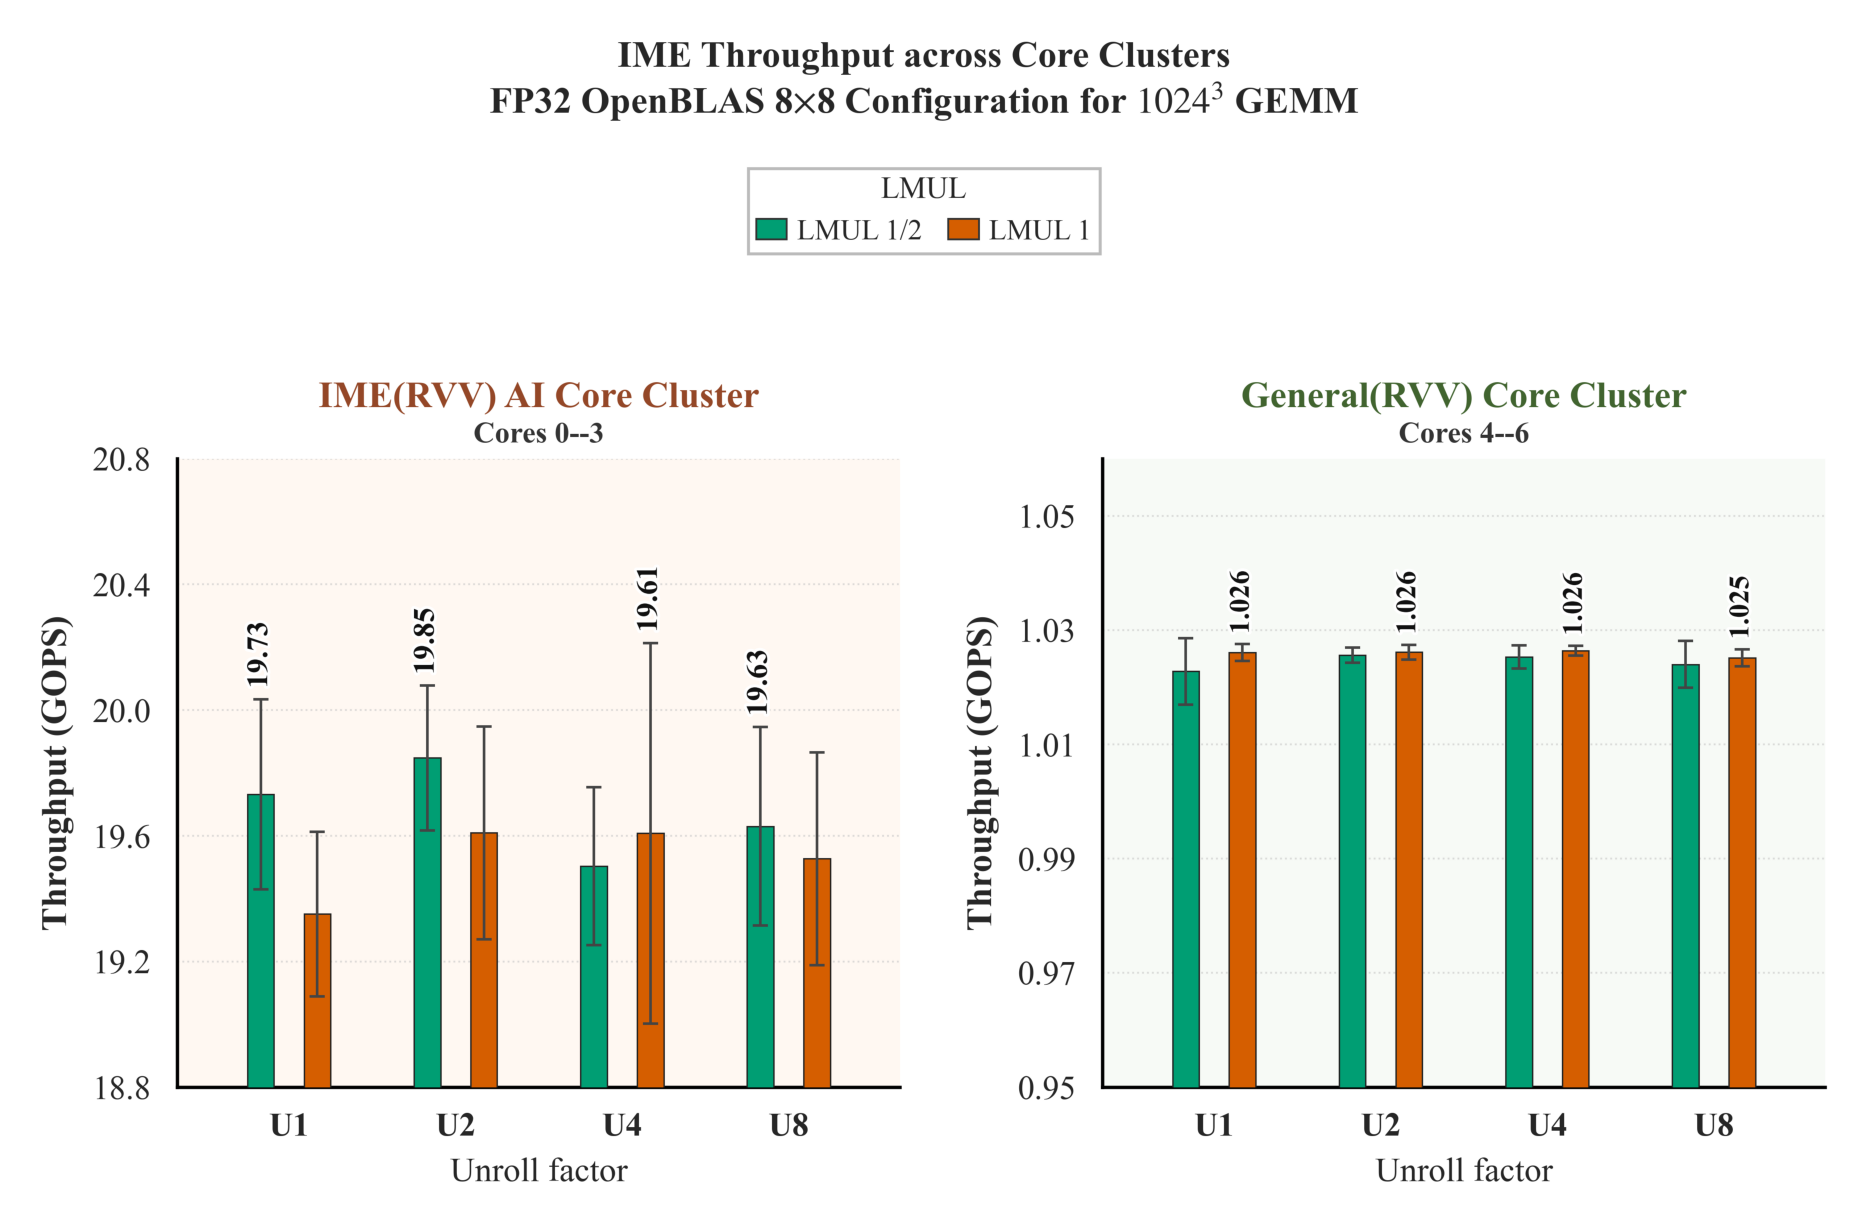

In [42]:
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.patheffects as pe
from matplotlib.patches import Patch

# ─────────────────────────────────────────────────────────────
# CLEAN START
# ─────────────────────────────────────────────────────────────
plt.close("all")

# ─────────────────────────────────────────────────────────────
# Springer / publication style — polished large-font version
# ─────────────────────────────────────────────────────────────
matplotlib.rcParams.update({
    "pdf.fonttype":       42,
    "ps.fonttype":        42,
    "font.family":        "serif",
    "font.serif":         ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset":   "stix",

    "axes.linewidth":     0.90,
    "xtick.major.width":  0.80,
    "ytick.major.width":  0.80,
    "xtick.minor.width":  0.60,
    "ytick.minor.width":  0.60,
    "xtick.major.size":   3.6,
    "ytick.major.size":   3.6,
    "xtick.direction":    "out",
    "ytick.direction":    "out",
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "figure.facecolor":   "white",
    "savefig.facecolor":  "white",
})

# ─────────────────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────────────────
OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

SAVE_PATH_PNG = os.path.join(
    OUTPUT_DIR,
    "ime_core_cluster_throughput_8x8_springer_polished_fp32config_2line.png"
)
SAVE_PATH_PDF = os.path.join(
    OUTPUT_DIR,
    "ime_core_cluster_throughput_8x8_springer_polished_fp32config_2line.pdf"
)

FIG_W, FIG_H = 6.8, 4.65
BAR_WIDTH    = 0.16
GROUP_WIDTH  = 0.34
CAPSIZE      = 2.0

# ─────────────────────────────────────────────────────────────
# DATA
# Fresh FP32-INT-IME 8x8 baseline summary_results_1024
# IME family separated by core clusters
# ─────────────────────────────────────────────────────────────
DATA = [
    # IME(RVV) AI Core Cluster, cores 0–3
    ("IME(RVV) AI Core Cluster", "1",   1, 19.351283333333, 0.261820596444),
    ("IME(RVV) AI Core Cluster", "1",   2, 19.609300000000, 0.338378077501),
    ("IME(RVV) AI Core Cluster", "1",   4, 19.607716666667, 0.605230750531),
    ("IME(RVV) AI Core Cluster", "1",   8, 19.526866666667, 0.338955285481),

    ("IME(RVV) AI Core Cluster", "mf2", 1, 19.732116666667, 0.302594356726),
    ("IME(RVV) AI Core Cluster", "mf2", 2, 19.847650000000, 0.230171289478),
    ("IME(RVV) AI Core Cluster", "mf2", 4, 19.503700000000, 0.251125917951),
    ("IME(RVV) AI Core Cluster", "mf2", 8, 19.630216666667, 0.315945941667),

    # General(RVV) Core Cluster, cores 4–6
    ("General(RVV) Core Cluster", "1",   1, 1.026050000000, 0.001480709289),
    ("General(RVV) Core Cluster", "1",   2, 1.026133333333, 0.001308519095),
    ("General(RVV) Core Cluster", "1",   4, 1.026366666667, 0.000859586464),
    ("General(RVV) Core Cluster", "1",   8, 1.025133333333, 0.001482865095),

    ("General(RVV) Core Cluster", "mf2", 1, 1.022766666667, 0.005837141614),
    ("General(RVV) Core Cluster", "mf2", 2, 1.025616666667, 0.001329682502),
    ("General(RVV) Core Cluster", "mf2", 4, 1.025300000000, 0.002059935274),
    ("General(RVV) Core Cluster", "mf2", 8, 1.024000000000, 0.004116632928),
]

df = pd.DataFrame(DATA, columns=["Family", "LMUL", "Unroll", "Mean", "Std"])

# ─────────────────────────────────────────────────────────────
# CONSTANTS
# ─────────────────────────────────────────────────────────────
FAMILIES = [
    "IME(RVV) AI Core Cluster",
    "General(RVV) Core Cluster",
]

UNROLLS    = [1, 2, 4, 8]
LMUL_ORDER = ["mf2", "1"]

LMUL_LABEL = {
    "mf2": "LMUL 1/2",
    "1":   "LMUL 1",
}

LMUL_COLORS = {
    "mf2": "#009E73",
    "1":   "#D55E00",
}

FAMILY_FACE = {
    "IME(RVV) AI Core Cluster":  "#FFF8F2",
    "General(RVV) Core Cluster": "#F7FAF6",
}

FAMILY_ACCENT = {
    "IME(RVV) AI Core Cluster":  "#944727",
    "General(RVV) Core Cluster": "#41642F",
}

FAMILY_SUBTITLE = {
    "IME(RVV) AI Core Cluster":  "Cores 0--3",
    "General(RVV) Core Cluster": "Cores 4--6",
}

UNROLL_LABEL = {
    1: "U1",
    2: "U2",
    4: "U4",
    8: "U8",
}

Y_LIMITS = {
    "IME(RVV) AI Core Cluster":  (18.8, 20.8),
    "General(RVV) Core Cluster": (0.95, 1.06),
}

Y_TICKS = {
    "IME(RVV) AI Core Cluster":  np.arange(18.8, 20.81, 0.4),
    "General(RVV) Core Cluster": np.arange(0.95, 1.061, 0.02),
}

LABEL_FONT = {
    "IME(RVV) AI Core Cluster":  8.0,
    "General(RVV) Core Cluster": 7.6,
}

LABEL_Y_OFFSET = {
    "IME(RVV) AI Core Cluster":  0.035,
    "General(RVV) Core Cluster": 0.0018,
}

VALUE_FORMAT = {
    "IME(RVV) AI Core Cluster":  "{:.2f}",
    "General(RVV) Core Cluster": "{:.3f}",
}

# ─────────────────────────────────────────────────────────────
# HELPERS
# ─────────────────────────────────────────────────────────────
def add_label(ax, x, y, text, fontsize):
    label = ax.text(
        x,
        y,
        text,
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=fontsize,
        fontweight="bold",
        color="#111111",
        zorder=8,
        clip_on=False,
    )
    label.set_path_effects([
        pe.Stroke(linewidth=1.60, foreground="white"),
        pe.Normal(),
    ])
    return label

# ─────────────────────────────────────────────────────────────
# FIGURE
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    1, 2,
    figsize=(FIG_W, FIG_H),
    dpi=300,
    constrained_layout=False,
    gridspec_kw={
        "wspace": 0.28,
        "width_ratios": [1, 1],
    },
)

fig.patch.set_facecolor("white")

# Two-line title
fig.suptitle(
    r"IME Throughput across Core Clusters"
    "\n"
    r"FP32 OpenBLAS 8$\times$8 Configuration for $1024^3$ GEMM",
    fontsize=10.0,
    fontweight="bold",
    y=0.975,
)

# ─────────────────────────────────────────────────────────────
# PANELS
# ─────────────────────────────────────────────────────────────
for ax, fam in zip(axes, FAMILIES):
    sub = df[df["Family"] == fam].copy()
    lmuls = [l for l in LMUL_ORDER if l in set(sub["LMUL"])]

    x = np.arange(len(UNROLLS))
    offsets = np.linspace(-GROUP_WIDTH / 2, GROUP_WIDTH / 2, len(lmuls))

    ax.set_facecolor(FAMILY_FACE[fam])
    bar_info = {}

    for offset, lmul in zip(offsets, lmuls):
        s = sub[sub["LMUL"] == lmul].set_index("Unroll").reindex(UNROLLS)
        vals = s["Mean"].values
        errs = s["Std"].values
        xpos = x + offset

        ax.bar(
            xpos,
            vals,
            width=BAR_WIDTH,
            color=LMUL_COLORS[lmul],
            edgecolor="#222222",
            linewidth=0.38,
            yerr=errs,
            capsize=CAPSIZE,
            error_kw=dict(
                elinewidth=0.70,
                ecolor="#444444",
                capthick=0.70,
            ),
            zorder=3,
        )

        for i, u in enumerate(UNROLLS):
            bar_info[(lmul, u)] = {
                "x": xpos[i],
                "mean": vals[i],
                "std": errs[i],
            }

    # Label only the best value per unroll group
    for u in UNROLLS:
        records_u = [bar_info[(lmul, u)] for lmul in lmuls]
        best_rec = max(records_u, key=lambda r: r["mean"])

        add_label(
            ax=ax,
            x=best_rec["x"],
            y=best_rec["mean"] + best_rec["std"] + LABEL_Y_OFFSET[fam],
            text=VALUE_FORMAT[fam].format(best_rec["mean"]),
            fontsize=LABEL_FONT[fam],
        )

    ax.set_title(
        fam,
        fontsize=10.0,
        fontweight="bold",
        color=FAMILY_ACCENT[fam],
        pad=14,
    )

    ax.text(
        0.5,
        1.016,
        FAMILY_SUBTITLE[fam],
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=8.0,
        fontweight="bold",
        color="#333333",
    )

    ax.set_xticks(x)
    ax.set_xticklabels(
        [UNROLL_LABEL[u] for u in UNROLLS],
        fontsize=9.0,
        fontweight="bold",
    )

    ax.set_xlabel("Unroll factor", fontsize=9.2, labelpad=4)
    ax.set_ylabel(
        "Throughput (GOPS)",
        fontsize=9.6,
        fontweight="bold",
        labelpad=5,
    )

    ax.set_ylim(*Y_LIMITS[fam])
    ax.set_yticks(Y_TICKS[fam])

    ax.yaxis.grid(
        True,
        linestyle=":",
        linewidth=0.50,
        color="#C7C7C7",
        alpha=0.60,
        zorder=0,
    )
    ax.grid(False, axis="x")

    ax.set_axisbelow(True)
    ax.tick_params(axis="y", labelsize=9.0)
    ax.margins(x=0.12)

# ─────────────────────────────────────────────────────────────
# LEGEND
# ─────────────────────────────────────────────────────────────
legend_handles = [
    Patch(
        facecolor=LMUL_COLORS[l],
        edgecolor="#333333",
        linewidth=0.50,
        label=LMUL_LABEL[l],
    )
    for l in LMUL_ORDER
]

fig.legend(
    handles=legend_handles,
    ncol=2,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.885),
    frameon=True,
    framealpha=1.0,
    fancybox=False,
    edgecolor="#BBBBBB",
    fontsize=7.8,
    title="LMUL",
    title_fontsize=8.2,
    borderpad=0.28,
    handlelength=1.05,
    handletextpad=0.35,
    columnspacing=0.90,
)

# ─────────────────────────────────────────────────────────────
# LAYOUT
# ─────────────────────────────────────────────────────────────
plt.subplots_adjust(
    left=0.090,
    right=0.995,
    bottom=0.135,
    top=0.640,
    wspace=0.28,
)

# ─────────────────────────────────────────────────────────────
# SAVE
# ─────────────────────────────────────────────────────────────
fig.savefig(SAVE_PATH_PNG, dpi=600, facecolor="white", bbox_inches="tight")
fig.savefig(SAVE_PATH_PDF, facecolor="white", bbox_inches="tight")

print(f"PNG: {os.path.abspath(SAVE_PATH_PNG)}")
print(f"PDF: {os.path.abspath(SAVE_PATH_PDF)}")

plt.close(fig)

# ─────────────────────────────────────────────────────────────
# DISPLAY IN NOTEBOOK — large preview for readability check
# ─────────────────────────────────────────────────────────────
fig_preview, ax_preview = plt.subplots(figsize=(13, 8.0), dpi=150)
img = mpimg.imread(SAVE_PATH_PNG)
ax_preview.imshow(img)
ax_preview.axis("off")
plt.tight_layout(pad=0)
plt.show()